<a href="https://colab.research.google.com/github/SJSUCMPE257/food-delivery-time-prediction/blob/main/notebooks/Food_Delivery_Preprocessing_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Food Delivery Time Prediction
## Data Preprocessing, Exploratory Data Analysis, and Feature Preparation

This Google Colab notebook prepares the [aneesarom/Food-Delivery](https://huggingface.co/datasets/aneesarom/Food-Delivery) dataset for a later regression model.

The notebook intentionally stops before predictive model training. It performs data quality auditing, duplicate analysis, missing-value analysis, deterministic cleaning, anomaly handling, feature engineering, exploratory data analysis, feature selection diagnostics, and leakage-safe preprocessing.

## 1. Environment and reproducibility

In [1]:
%%capture
!pip -q install "datasets>=2.18" "pyarrow>=14" "missingno>=0.5"

<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The required data access and analysis packages are installed. Re-run this cell after a fresh Colab runtime before executing the remaining cells.
</div>

In [2]:
import hashlib
import json
import math
import os
import platform
import re
import shutil
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import sparse
from scipy.spatial.distance import jensenshannon
from scipy.sparse import save_npz
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATASET_ID = "aneesarom/Food-Delivery"
TARGET_COLUMN = "target_minutes"
SPLIT_RATIOS = {"train": 0.70, "validation": 0.15, "test": 0.15}
OUTPUT_DIR = Path("/content/food_delivery_artifacts")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
DEFAULT_PLOT_COLOR = sns.color_palette()[0]
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

runtime_info = pd.DataFrame(
    {
        "item": [
            "Python",
            "pandas",
            "NumPy",
            "scikit-learn",
            "platform",
            "random_state",
            "output_directory",
        ],
        "value": [
            sys.version.split()[0],
            pd.__version__,
            np.__version__,
            __import__("sklearn").__version__,
            platform.platform(),
            RANDOM_STATE,
            str(OUTPUT_DIR),
        ],
    }
)
display(runtime_info)

,item,value
0,Python,3.12.13
1,pandas,2.2.2
2,NumPy,2.0.2
3,scikit-learn,1.6.1
4,platform,Linux-6.6.122+-x86_64-with-glibc2.35
5,random_state,42
6,output_directory,/content/food_delivery_artifacts


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The runtime configuration, package versions, random seed, and output location are recorded. These values make later results easier to reproduce and diagnose.
</div>

In [3]:
def dataframe_fingerprint(frame: pd.DataFrame) -> str:
    """Create a deterministic SHA-256 fingerprint from dataframe values and index."""
    normalized = frame.copy()
    for column in normalized.columns:
        normalized[column] = normalized[column].astype("string").fillna("<NA>")
    row_hashes = pd.util.hash_pandas_object(normalized, index=True).to_numpy()
    return hashlib.sha256(row_hashes.tobytes()).hexdigest()


def memory_usage_mb(frame: pd.DataFrame) -> float:
    """Return total dataframe memory usage in megabytes."""
    return frame.memory_usage(deep=True).sum() / (1024**2)


def compact_display(frame: pd.DataFrame, rows: int = 10) -> None:
    """Display a dataframe with a compact default row limit."""
    display(frame.head(rows))

<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
Reusable helpers are now available for dataset fingerprinting, memory reporting, and compact table display. No dataset values are changed in this cell.
</div>

## 2. Load the source dataset and preserve raw data

In [4]:
from datasets import load_dataset

source_dataset = load_dataset(DATASET_ID)
required_source_splits = {"train", "test"}
missing_source_splits = required_source_splits.difference(source_dataset.keys())

if missing_source_splits:
    raise KeyError(f"Missing expected source splits: {sorted(missing_source_splits)}")

source_train = source_dataset["train"].to_pandas().reset_index(drop=True)
source_test = source_dataset["test"].to_pandas().reset_index(drop=True)

source_train["source_split"] = "train"
source_test["source_split"] = "test"
source_train["source_row_number"] = np.arange(len(source_train), dtype=np.int64)
source_test["source_row_number"] = np.arange(len(source_test), dtype=np.int64)

source_overview = pd.DataFrame(
    {
        "source_split": ["train", "test"],
        "rows": [len(source_train), len(source_test)],
        "columns": [source_train.shape[1], source_test.shape[1]],
        "memory_mb": [memory_usage_mb(source_train), memory_usage_mb(source_test)],
    }
)
display(source_overview)

README.md:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.76MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  447kB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/36467 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/9117 [00:00<?, ? examples/s]

,source_split,rows,columns,memory_mb
0,train,36467,22,26.0057
1,test,9117,22,6.4936


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
Both Hugging Face source partitions are loaded and labeled with provenance columns. These original partitions will not be used as the final evaluation split because the project requires a custom 70/15/15 allocation.
</div>

In [5]:
if set(source_train.columns) != set(source_test.columns):
    train_only_columns = sorted(set(source_train.columns) - set(source_test.columns))
    test_only_columns = sorted(set(source_test.columns) - set(source_train.columns))
    raise ValueError(
        f"Source schema mismatch. Train-only: {train_only_columns}; "
        f"Test-only: {test_only_columns}"
    )

full_raw = pd.concat([source_train, source_test], ignore_index=True, sort=False)
full_raw_backup = full_raw.copy(deep=True)

source_fingerprints = pd.DataFrame(
    {
        "object": ["source_train", "source_test", "full_raw"],
        "rows": [len(source_train), len(source_test), len(full_raw)],
        "columns": [source_train.shape[1], source_test.shape[1], full_raw.shape[1]],
        "sha256_fingerprint": [
            dataframe_fingerprint(source_train),
            dataframe_fingerprint(source_test),
            dataframe_fingerprint(full_raw),
        ],
    }
)
display(source_fingerprints)

,object,rows,columns,sha256_fingerprint
0,source_train,36467,22,c5100086faf11a3fcf0bce602b78643f3a30b0cc362a3c...
1,source_test,9117,22,f9372e5414ce188805a8e925daede66b765510fd6a4754...
2,full_raw,45584,22,a3dfa7a0eeef72be08777e5854e1b7b1b6c2d466624355...


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The source schemas match, and the partitions are combined without losing provenance. Fingerprints provide a reference for detecting accidental source-data changes in later runs.
</div>

In [6]:
print(f"Combined shape: {full_raw.shape}")
print(f"Combined memory usage: {memory_usage_mb(full_raw):,.2f} MB")
print("\nColumn names:")
print(full_raw.columns.tolist())

display(full_raw.head(5))

Combined shape: (45584, 22)
Combined memory usage: 32.50 MB

Column names:
['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)', 'source_split', 'source_row_number']


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),source_split,source_row_number
0,0x6bbb,INDORES02DEL01,23.0000,4.5000,22.6518,75.8820,22.7218,75.9520,18-03-2022,22:10,22:25,Stormy,Low,1,Buffet,motorcycle,1.0000,No,Metropolitian,17,train,0
1,0x190a,MYSRES20DEL01,39.0000,4.3000,12.3380,76.6168,12.3780,76.6568,17-03-2022,15:10,15:20,Cloudy,Medium,0,Buffet,motorcycle,1.0000,No,Metropolitian,33,train,1
2,0x120c,MYSRES07DEL02,37.0000,4.8000,12.3255,76.6323,12.3755,76.6823,03-03-2022,23:55,24:10:00,Windy,Low,2,Meal,scooter,0.0000,No,None,20,train,2
3,0x6016,SURRES12DEL03,30.0000,4.8000,21.1834,72.8145,21.2134,72.8445,05-03-2022,17:35,17:40,Sandstorms,Medium,0,Snack,motorcycle,0.0000,No,Metropolitian,27,train,3
4,0x9ca0,VADRES13DEL02,29.0000,4.6000,22.3102,73.1589,22.3602,73.2089,11-03-2022,21:30,21:45,Cloudy,Jam,2,Buffet,scooter,0.0000,No,Metropolitian,26,train,4


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
This output confirms the combined dataset dimensions, memory footprint, column names, and several raw examples. The sample should still contain the original naming and formatting issues because cleaning has not started.
</div>

### Data dictionary and availability policy

| Standardized field | Role | Expected interpretation | Main model status |
|---|---|---|---|
| `order_id` | Identifier | Unique order record | Exclude |
| `delivery_person_id` | Composite operational identifier | City, restaurant, and delivery code | Parse, then exclude raw ID |
| `delivery_person_age` | Numeric feature | Driver age | Include after validation and imputation |
| `delivery_person_ratings` | Numeric feature | Driver rating | Include after validation and imputation |
| `restaurant_latitude`, `restaurant_longitude` | Raw location | Restaurant coordinates | Use for deterministic distance, then exclude raw coordinates |
| `delivery_location_latitude`, `delivery_location_longitude` | Raw location | Delivery coordinates | Use for deterministic distance, then exclude raw coordinates |
| `order_date` | Raw date | Order calendar date | Derive calendar features, then exclude raw date |
| `time_ordered` | Raw time | Order placement time | Derive time features, then exclude raw text |
| `time_order_picked` | Raw time | Pickup time | Exclude from main model |
| `weather_conditions` | Categorical feature | Weather at order time | Include |
| `road_traffic_density` | Categorical feature | Traffic state | Include |
| `vehicle_condition` | Categorical feature | Vehicle condition code | Include after anomaly handling |
| `order_type` | Categorical feature | Meal, snack, drinks, or buffet | Include |
| `vehicle_type` | Categorical feature | Delivery vehicle type | Include |
| `multiple_deliveries` | Discrete numeric feature | Concurrent delivery count | Include after validation and imputation |
| `festival` | Categorical feature | Festival indicator | Include |
| `area_type` | Categorical feature | Metropolitan, urban, or semi-urban area | Include |
| `target_minutes` | Target | Total delivery time in minutes | Target only |
| `source_split`, `source_row_number` | Provenance | Original source location | Exclude |

## 3. Standardize the raw schema and audit duplicates

In [7]:
RAW_TO_STANDARD = {
    "ID": "order_id",
    "Delivery_person_ID": "delivery_person_id",
    "Delivery_person_Age": "delivery_person_age",
    "Delivery_person_Ratings": "delivery_person_ratings",
    "Restaurant_latitude": "restaurant_latitude",
    "Restaurant_longitude": "restaurant_longitude",
    "Delivery_location_latitude": "delivery_location_latitude",
    "Delivery_location_longitude": "delivery_location_longitude",
    "Order_Date": "order_date",
    "Time_Orderd": "time_ordered",
    "Time_Order_picked": "time_order_picked",
    "Weather_conditions": "weather_conditions",
    "Road_traffic_density": "road_traffic_density",
    "Vehicle_condition": "vehicle_condition",
    "Type_of_order": "order_type",
    "Type_of_vehicle": "vehicle_type",
    "Festival": "festival",
    "City": "area_type",
    "Time_taken (min)": "target_minutes",
}

NULL_TOKENS = {"", "nan", "none", "null", "na", "n/a", "<na>"}


def normalize_text_series(series: pd.Series) -> pd.Series:
    text = series.astype("string").str.strip().str.replace(r"\s+", " ", regex=True)
    return text.mask(text.str.lower().isin(NULL_TOKENS), pd.NA)


def normalize_raw_schema(frame: pd.DataFrame) -> pd.DataFrame:
    """Apply deterministic naming, text normalization, and basic type coercion."""
    output = frame.rename(columns=RAW_TO_STANDARD).copy()

    for column in output.select_dtypes(include=["object", "string"]).columns:
        output[column] = normalize_text_series(output[column])

    if "delivery_person_id" in output:
        output["delivery_person_id"] = output["delivery_person_id"].str.upper()

    title_case_columns = [
        "weather_conditions",
        "road_traffic_density",
        "order_type",
        "festival",
        "area_type",
    ]
    for column in title_case_columns:
        if column in output:
            output[column] = output[column].str.title()

    if "vehicle_type" in output:
        output["vehicle_type"] = (
            output["vehicle_type"]
            .str.lower()
            .str.replace(r"\s+", "_", regex=True)
        )

    if "area_type" in output:
        output["area_type"] = output["area_type"].replace(
            {"Metropolitian": "Metropolitan"}
        )

    numeric_columns = [
        "delivery_person_age",
        "delivery_person_ratings",
        "restaurant_latitude",
        "restaurant_longitude",
        "delivery_location_latitude",
        "delivery_location_longitude",
        "vehicle_condition",
        "multiple_deliveries",
        "target_minutes",
        "source_row_number",
    ]
    for column in numeric_columns:
        if column in output:
            output[column] = pd.to_numeric(output[column], errors="coerce")

    return output


full_standard = normalize_raw_schema(full_raw)
print(full_standard.columns.tolist())
display(full_standard.head(3))

['order_id', 'delivery_person_id', 'delivery_person_age', 'delivery_person_ratings', 'restaurant_latitude', 'restaurant_longitude', 'delivery_location_latitude', 'delivery_location_longitude', 'order_date', 'time_ordered', 'time_order_picked', 'weather_conditions', 'road_traffic_density', 'vehicle_condition', 'order_type', 'vehicle_type', 'multiple_deliveries', 'festival', 'area_type', 'target_minutes', 'source_split', 'source_row_number']


,order_id,delivery_person_id,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,time_order_picked,weather_conditions,road_traffic_density,vehicle_condition,order_type,vehicle_type,multiple_deliveries,festival,area_type,target_minutes,source_split,source_row_number
0,0x6bbb,INDORES02DEL01,23.0000,4.5000,22.6518,75.8820,22.7218,75.9520,18-03-2022,22:10,22:25,Stormy,Low,1,Buffet,motorcycle,1.0000,No,Metropolitan,17,train,0
1,0x190a,MYSRES20DEL01,39.0000,4.3000,12.3380,76.6168,12.3780,76.6568,17-03-2022,15:10,15:20,Cloudy,Medium,0,Buffet,motorcycle,1.0000,No,Metropolitan,33,train,1
2,0x120c,MYSRES07DEL02,37.0000,4.8000,12.3255,76.6323,12.3755,76.6823,03-03-2022,23:55,24:10:00,Windy,Low,2,Meal,scooter,0.0000,No,<NA>,20,train,2


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
Column names now follow a consistent English snake-case schema, surrounding whitespace is removed, common null tokens become missing values, and known category spelling is standardized. These operations are deterministic and do not learn from validation or test data.
</div>

In [8]:
provenance_columns = ["source_split", "source_row_number"]
data_columns = [column for column in full_standard.columns if column not in provenance_columns]
feature_columns_without_target = [
    column for column in data_columns if column != TARGET_COLUMN
]

exact_duplicate_mask = full_standard.duplicated(subset=data_columns, keep=False)
order_id_duplicate_mask = full_standard["order_id"].duplicated(keep=False)
feature_hash = pd.util.hash_pandas_object(
    full_standard[feature_columns_without_target], index=False
)
feature_target_audit = pd.DataFrame(
    {"feature_hash": feature_hash, "target": full_standard[TARGET_COLUMN]}
)
feature_group_target_counts = feature_target_audit.groupby("feature_hash")["target"].nunique()

business_key = [
    "delivery_person_id",
    "order_date",
    "time_ordered",
    "restaurant_latitude",
    "restaurant_longitude",
    "delivery_location_latitude",
    "delivery_location_longitude",
]
business_key_duplicate_mask = full_standard.duplicated(subset=business_key, keep=False)

duplicate_audit = pd.DataFrame(
    {
        "check": [
            "exact_duplicate_rows",
            "duplicate_order_id_rows",
            "feature_duplicate_groups",
            "feature_groups_with_conflicting_targets",
            "business_key_duplicate_rows",
        ],
        "count": [
            int(exact_duplicate_mask.sum()),
            int(order_id_duplicate_mask.sum()),
            int((feature_hash.value_counts() > 1).sum()),
            int((feature_group_target_counts > 1).sum()),
            int(business_key_duplicate_mask.sum()),
        ],
    }
)
display(duplicate_audit)

,check,count
0,exact_duplicate_rows,0
1,duplicate_order_id_rows,0
2,feature_duplicate_groups,0
3,feature_groups_with_conflicting_targets,0
4,business_key_duplicate_rows,0


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The table distinguishes exact duplicates, repeated order IDs, feature duplicates, conflicting targets, and repeated business keys. Exact duplicates may be removed before splitting, while conflicting feature duplicates should be investigated rather than deleted automatically.
</div>

In [9]:
full_unique = full_standard.drop_duplicates(subset=data_columns, keep="first").copy()
full_unique = full_unique.reset_index(drop=True)

if not full_unique["order_id"].is_unique:
    duplicated_ids = full_unique.loc[
        full_unique["order_id"].duplicated(keep=False), "order_id"
    ].dropna().unique()[:10]
    raise ValueError(
        "Order IDs are not unique after exact deduplication. "
        f"Examples: {duplicated_ids.tolist()}"
    )

removed_exact_duplicates = len(full_standard) - len(full_unique)
print(f"Rows before exact deduplication: {len(full_standard):,}")
print(f"Rows after exact deduplication:  {len(full_unique):,}")
print(f"Exact duplicate rows removed:    {removed_exact_duplicates:,}")

Rows before exact deduplication: 45,584
Rows after exact deduplication:  45,584
Exact duplicate rows removed:    0


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
Only fully identical records are removed, which prevents identical rows from crossing evaluation boundaries. Non-identical repeated business events are retained because they may represent legitimate variation.
</div>

## 4. Create the chronological 70/15/15 split

In [10]:
def allocate_integer_split_counts(total_rows: int, ratios: dict[str, float]) -> dict[str, int]:
    """Allocate integer row counts using the largest-remainder method."""
    ratio_sum = sum(ratios.values())
    if not math.isclose(ratio_sum, 1.0, rel_tol=0, abs_tol=1e-12):
        raise ValueError(f"Split ratios must sum to 1.0, received {ratio_sum}")

    raw_counts = {name: total_rows * ratio for name, ratio in ratios.items()}
    counts = {name: math.floor(value) for name, value in raw_counts.items()}
    rows_left = total_rows - sum(counts.values())

    ranked_remainders = sorted(
        ratios,
        key=lambda name: (raw_counts[name] - counts[name], ratios[name]),
        reverse=True,
    )
    for name in ranked_remainders[:rows_left]:
        counts[name] += 1

    return counts


split_frame = full_unique.copy()
split_frame["_split_date"] = pd.to_datetime(
    split_frame["order_date"], dayfirst=True, errors="coerce"
)

if split_frame["_split_date"].isna().any():
    bad_dates = split_frame.loc[
        split_frame["_split_date"].isna(), ["order_id", "order_date"]
    ].head(20)
    display(bad_dates)
    raise ValueError("Unparseable order dates must be resolved before chronological splitting.")

split_frame["_tie_breaker"] = pd.util.hash_pandas_object(
    split_frame["order_id"].astype("string"), index=False
).astype("uint64")

split_frame = split_frame.sort_values(
    ["_split_date", "_tie_breaker"], kind="mergesort"
).reset_index(drop=True)

split_counts = allocate_integer_split_counts(len(split_frame), SPLIT_RATIOS)
train_end = split_counts["train"]
validation_end = train_end + split_counts["validation"]

train_raw = split_frame.iloc[:train_end].drop(columns=["_split_date", "_tie_breaker"]).copy()
validation_raw = split_frame.iloc[train_end:validation_end].drop(
    columns=["_split_date", "_tie_breaker"]
).copy()
test_raw = split_frame.iloc[validation_end:].drop(
    columns=["_split_date", "_tie_breaker"]
).copy()

for frame in (train_raw, validation_raw, test_raw):
    frame.reset_index(drop=True, inplace=True)

print(split_counts)

{'train': 31909, 'validation': 6838, 'test': 6837}


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The combined dataset is ordered chronologically and allocated with deterministic integer counts. The largest-remainder method keeps the achieved proportions as close as mathematically possible to 70%, 15%, and 15%.
</div>

In [11]:
def split_summary(name: str, frame: pd.DataFrame) -> dict:
    parsed_dates = pd.to_datetime(frame["order_date"], dayfirst=True, errors="coerce")
    return {
        "split": name,
        "rows": len(frame),
        "share": len(frame) / len(split_frame),
        "min_order_date": parsed_dates.min(),
        "max_order_date": parsed_dates.max(),
        "unique_order_ids": frame["order_id"].nunique(dropna=True),
        "source_train_rows": int((frame["source_split"] == "train").sum()),
        "source_test_rows": int((frame["source_split"] == "test").sum()),
    }


split_summary_table = pd.DataFrame(
    [
        split_summary("train", train_raw),
        split_summary("validation", validation_raw),
        split_summary("test", test_raw),
    ]
)
display(split_summary_table)

train_ids = set(train_raw["order_id"].dropna())
validation_ids = set(validation_raw["order_id"].dropna())
test_ids = set(test_raw["order_id"].dropna())

assert len(train_raw) + len(validation_raw) + len(test_raw) == len(split_frame)
assert train_ids.isdisjoint(validation_ids)
assert train_ids.isdisjoint(test_ids)
assert validation_ids.isdisjoint(test_ids)

train_dates = pd.to_datetime(train_raw["order_date"], dayfirst=True)
validation_dates = pd.to_datetime(validation_raw["order_date"], dayfirst=True)
test_dates = pd.to_datetime(test_raw["order_date"], dayfirst=True)

assert train_dates.max() <= validation_dates.min()
assert validation_dates.max() <= test_dates.min()

print("Split overlap and chronological-order assertions passed.")

,split,rows,share,min_order_date,max_order_date,unique_order_ids,source_train_rows,source_test_rows
0,train,31909,0.7000,2022-02-11,2022-03-25,31909,25538,6371
1,validation,6838,0.1500,2022-03-25,2022-03-31,6838,5460,1378
2,test,6837,0.1500,2022-03-31,2022-04-06,6837,5469,1368


Split overlap and chronological-order assertions passed.


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The summary verifies row counts, achieved percentages, date ranges, source composition, and unique IDs. Passing assertions confirm that no order ID crosses splits and that the split order moves from earlier to later dates.
</div>

In [12]:
feature_availability_policy = pd.DataFrame(
    [
        ("order_id", "identifier", "exclude", "Unique technical identifier"),
        ("delivery_person_id", "identifier", "parse then exclude", "High-cardinality composite code"),
        ("source_split", "provenance", "exclude", "Original source partition"),
        ("source_row_number", "provenance", "exclude", "Original row position"),
        ("order_date", "raw time", "derive then exclude", "Use calendar derivatives"),
        ("time_ordered", "raw time", "derive then exclude", "Use parsed order-time derivatives"),
        ("time_order_picked", "post-order information", "exclude", "Unavailable at the main prediction point"),
        ("pickup_datetime", "post-order information", "exclude", "Derived from pickup time"),
        ("pickup_hour", "post-order information", "exclude", "Derived from pickup time"),
        ("prep_time_minutes", "post-order information", "exclude", "Uses pickup time"),
        ("restaurant coordinates", "raw location", "derive then exclude", "Use distance and quality flags"),
        ("delivery coordinates", "raw location", "derive then exclude", "Use distance and quality flags"),
        ("target_minutes", "target", "target only", "Never included in X"),
    ],
    columns=["field", "role", "main_model_action", "reason"],
)
display(feature_availability_policy)

,field,role,main_model_action,reason
0,order_id,identifier,exclude,Unique technical identifier
1,delivery_person_id,identifier,parse then exclude,High-cardinality composite code
2,source_split,provenance,exclude,Original source partition
3,source_row_number,provenance,exclude,Original row position
4,order_date,raw time,derive then exclude,Use calendar derivatives
5,time_ordered,raw time,derive then exclude,Use parsed order-time derivatives
6,time_order_picked,post-order information,exclude,Unavailable at the main prediction point
7,pickup_datetime,post-order information,exclude,Derived from pickup time
8,pickup_hour,post-order information,exclude,Derived from pickup time
9,prep_time_minutes,post-order information,exclude,Uses pickup time


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The leakage policy is explicit before EDA and feature engineering. Any later feature list must comply with this table, especially the exclusion of pickup-derived information from the main prediction scenario.
</div>

## 5. Audit the raw training split only

In [13]:
training_schema_report = pd.DataFrame(
    {
        "column": train_raw.columns,
        "dtype": [str(train_raw[column].dtype) for column in train_raw.columns],
        "non_null": [train_raw[column].notna().sum() for column in train_raw.columns],
        "missing": [train_raw[column].isna().sum() for column in train_raw.columns],
        "unique": [train_raw[column].nunique(dropna=True) for column in train_raw.columns],
    }
).sort_values(["missing", "unique"], ascending=[False, False])

display(training_schema_report)

,column,dtype,non_null,missing,unique
3,delivery_person_ratings,float64,30561,1348,28
2,delivery_person_age,float64,30615,1294,22
9,time_ordered,string,30677,1232,176
18,area_type,string,31088,821,3
16,multiple_deliveries,float64,31208,701,4
11,weather_conditions,string,31469,440,6
12,road_traffic_density,string,31484,425,4
17,festival,string,31761,148,2
0,order_id,string,31909,0,31909
21,source_row_number,int64,31909,0,27499


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
This table is the training-only schema baseline. It identifies incorrect dtypes, missing fields, and high-cardinality columns without using validation or test values to guide decisions.
</div>

,missing_count,missing_rate
delivery_person_ratings,1348,0.0422
delivery_person_age,1294,0.0406
time_ordered,1232,0.0386
area_type,821,0.0257
multiple_deliveries,701,0.0220
weather_conditions,440,0.0138
road_traffic_density,425,0.0133
festival,148,0.0046


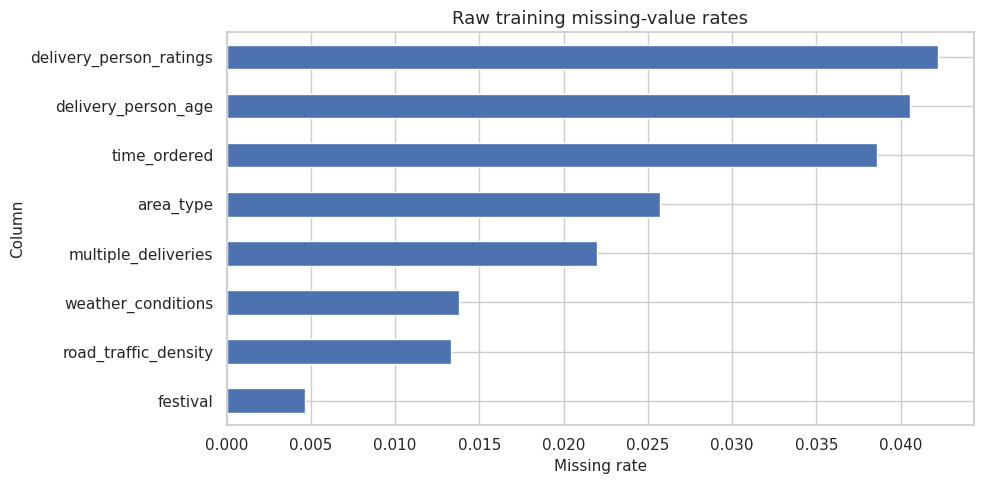

In [14]:
missing_table_raw = (
    train_raw.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_rate=lambda table: table["missing_count"] / len(train_raw))
    .query("missing_count > 0")
    .sort_values("missing_rate", ascending=False)
)
display(missing_table_raw)

if not missing_table_raw.empty:
    ax = missing_table_raw["missing_rate"].sort_values().plot(kind="barh")
    ax.set_title("Raw training missing-value rates")
    ax.set_xlabel("Missing rate")
    ax.set_ylabel("Column")
    plt.tight_layout()
    plt.show()

<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The table and chart show which raw training columns require a missing-value strategy. Rows are not dropped simply because one field is missing, because missingness may be informative and affects a meaningful share of the data.
</div>

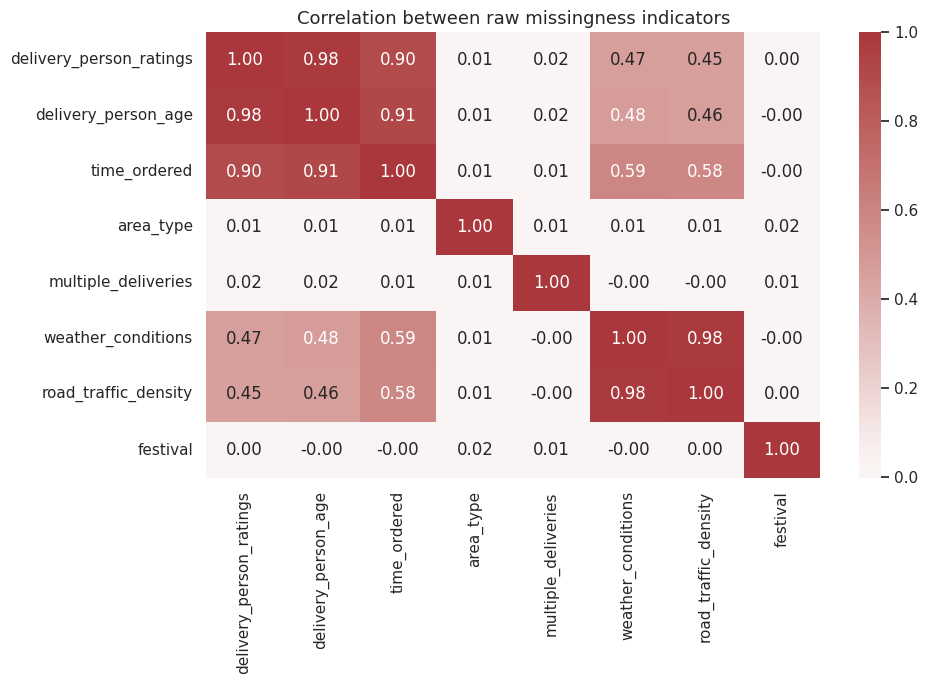

,missing_pattern,rows,rate
0,Complete,28954,0.9074
1,area_type,742,0.0233
2,delivery_person_ratings | delivery_person_age ...,736,0.0231
3,multiple_deliveries,627,0.0196
4,delivery_person_ratings | delivery_person_age ...,331,0.0104
5,festival,128,0.0040
6,delivery_person_ratings | delivery_person_age,124,0.0039
7,time_ordered | weather_conditions | road_traff...,71,0.0022
8,delivery_person_ratings,51,0.0016
9,delivery_person_ratings | delivery_person_age ...,27,0.0008


In [15]:
missing_columns_raw = missing_table_raw.index.tolist()

if missing_columns_raw:
    missing_indicator_matrix = train_raw[missing_columns_raw].isna().astype(int)
    missing_correlation = missing_indicator_matrix.corr()

    plt.figure(figsize=(10, 7))
    sns.heatmap(missing_correlation, annot=True, fmt=".2f", center=0, cmap="vlag")
    plt.title("Correlation between raw missingness indicators")
    plt.tight_layout()
    plt.show()

    missing_signatures = train_raw[missing_columns_raw].isna().apply(
        lambda row: " | ".join(row.index[row].tolist()) if row.any() else "Complete",
        axis=1,
    )
    missing_pattern_table = (
        missing_signatures.value_counts(dropna=False)
        .rename_axis("missing_pattern")
        .reset_index(name="rows")
        .assign(rate=lambda table: table["rows"] / len(train_raw))
        .head(20)
    )
    display(missing_pattern_table)
else:
    print("No raw missing values were detected.")

<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
Missingness correlations and common patterns reveal whether fields tend to disappear together. Strong co-missing patterns can indicate a data collection state rather than independent random missing values.
</div>

In [16]:
train_duplicate_audit = pd.DataFrame(
    {
        "check": [
            "exact_duplicate_rows",
            "duplicate_order_id_rows",
            "business_key_duplicate_rows",
        ],
        "count": [
            int(train_raw.duplicated(subset=data_columns, keep=False).sum()),
            int(train_raw["order_id"].duplicated(keep=False).sum()),
            int(train_raw.duplicated(subset=business_key, keep=False).sum()),
        ],
    }
)
display(train_duplicate_audit)

,check,count
0,exact_duplicate_rows,0
1,duplicate_order_id_rows,0
2,business_key_duplicate_rows,0


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
This training-only duplicate check confirms that the custom split did not introduce repeated identifiers or exact rows. Business-key repeats are reported separately because they may be legitimate orders with similar operational attributes.
</div>

In [17]:
raw_categorical_columns = [
    "weather_conditions",
    "road_traffic_density",
    "order_type",
    "vehicle_type",
    "festival",
    "area_type",
]

raw_category_report = pd.DataFrame(
    {
        "column": raw_categorical_columns,
        "unique_non_null": [train_raw[column].nunique(dropna=True) for column in raw_categorical_columns],
        "missing_rate": [train_raw[column].isna().mean() for column in raw_categorical_columns],
        "smallest_category_count": [
            train_raw[column].value_counts(dropna=True).min()
            if train_raw[column].notna().any()
            else 0
            for column in raw_categorical_columns
        ],
        "largest_category_share": [
            train_raw[column].value_counts(normalize=True, dropna=True).max()
            if train_raw[column].notna().any()
            else np.nan
            for column in raw_categorical_columns
        ],
    }
)
display(raw_category_report)

for column in raw_categorical_columns:
    print(f"\n{column}")
    display(
        train_raw[column]
        .fillna("<MISSING>")
        .value_counts(dropna=False)
        .rename_axis("value")
        .reset_index(name="rows")
        .assign(rate=lambda table: table["rows"] / len(train_raw))
    )

,column,unique_non_null,missing_rate,smallest_category_count,largest_category_share
0,weather_conditions,6,0.0138,5095,0.1702
1,road_traffic_density,4,0.0133,3125,0.3457
2,order_type,4,0.0000,7883,0.2531
3,vehicle_type,4,0.0000,55,0.5804
4,festival,2,0.0046,615,0.9806
5,area_type,3,0.0257,110,0.7657



weather_conditions


,value,rows,rate
0,Fog,5355,0.1678
1,Stormy,5336,0.1672
2,Cloudy,5299,0.1661
3,Sandstorms,5219,0.1636
4,Windy,5165,0.1619
5,Sunny,5095,0.1597
6,<MISSING>,440,0.0138



road_traffic_density


,value,rows,rate
0,Low,10883,0.3411
1,Jam,9810,0.3074
2,Medium,7666,0.2402
3,High,3125,0.0979
4,<MISSING>,425,0.0133


...

,value,rows,rate
0,motorcycle,18519,0.5804
1,scooter,10637,0.3334
2,electric_scooter,2698,0.0846
3,bicycle,55,0.0017



festival


,value,rows,rate
0,No,31146,0.9761
1,Yes,615,0.0193
2,<MISSING>,148,0.0046



area_type


,value,rows,rate
0,Metropolitan,23805,0.7460
1,Urban,7173,0.2248
2,<MISSING>,821,0.0257
3,Semi-Urban,110,0.0034


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The categorical audit exposes rare levels, dominant levels, missing categories, and spelling variants. Rare categories are retained for now and handled later by train-fitted one-hot encoding with a minimum-frequency rule.
</div>

In [18]:
domain_rules = {
    "delivery_person_age": lambda series: series.notna() & ~series.between(18, 65),
    "delivery_person_ratings": lambda series: series.notna() & ~series.between(1, 5),
    "restaurant_latitude": lambda series: series.notna() & ~series.between(-90, 90),
    "restaurant_longitude": lambda series: series.notna() & ~series.between(-180, 180),
    "delivery_location_latitude": lambda series: series.notna() & ~series.between(-90, 90),
    "delivery_location_longitude": lambda series: series.notna() & ~series.between(-180, 180),
    "vehicle_condition": lambda series: series.notna() & ~series.isin([0, 1, 2, 3]),
    "multiple_deliveries": lambda series: series.notna() & ~series.between(0, 3),
    "target_minutes": lambda series: series.isna() | (series <= 0),
}

domain_audit_rows = []
for column, rule in domain_rules.items():
    numeric_series = pd.to_numeric(train_raw[column], errors="coerce")
    invalid_mask = rule(numeric_series)
    domain_audit_rows.append(
        {
            "column": column,
            "invalid_rows": int(invalid_mask.sum()),
            "missing_rows": int(numeric_series.isna().sum()),
            "minimum": numeric_series.min(),
            "maximum": numeric_series.max(),
        }
    )

domain_audit = pd.DataFrame(domain_audit_rows)
display(domain_audit)

,column,invalid_rows,missing_rows,minimum,maximum
0,delivery_person_age,26,1294,15.0000,50.0000
1,delivery_person_ratings,47,1348,1.0000,6.0000
2,restaurant_latitude,0,0,-30.9056,30.9141
3,restaurant_longitude,0,0,-88.3662,88.4335
4,delivery_location_latitude,0,0,0.0100,31.0541
5,delivery_location_longitude,0,0,0.0100,88.5635
6,vehicle_condition,0,0,0.0000,3.0000
7,multiple_deliveries,0,701,0.0000,3.0000
8,target_minutes,0,0,10.0000,54.0000


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The domain audit separates missing values from values outside plausible business ranges. Invalid feature values will become missing values with explicit quality flags rather than being silently clipped.
</div>

## 6. Define deterministic cleaning and base feature engineering

In [19]:
CLOCK_PATTERN = re.compile(r"^(?P<hour>\d{1,2}):(?P<minute>\d{1,2})(?::(?P<second>\d{1,2}(?:\.\d+)?))?$")
NUMERIC_PATTERN = re.compile(r"^[+-]?(?:\d+(?:\.\d*)?|\.\d+)$")


def parse_clock_value(value) -> dict:
    """Parse clock strings, 24+ hour strings, and Excel day fractions."""
    if pd.isna(value):
        return {
            "minute_of_day": np.nan,
            "day_offset": np.nan,
            "format": "missing",
            "parse_failed": 0,
        }

    text = str(value).strip()
    if not text:
        return {
            "minute_of_day": np.nan,
            "day_offset": np.nan,
            "format": "missing",
            "parse_failed": 0,
        }

    if NUMERIC_PATTERN.fullmatch(text):
        numeric_value = float(text)
        if 0 <= numeric_value <= 2:
            total_seconds = int(round(numeric_value * 24 * 60 * 60))
            return {
                "minute_of_day": (total_seconds % 86400) / 60,
                "day_offset": total_seconds // 86400,
                "format": "excel_fraction",
                "parse_failed": 0,
            }

    match = CLOCK_PATTERN.fullmatch(text)
    if match:
        hour = int(match.group("hour"))
        minute = int(match.group("minute"))
        second = float(match.group("second") or 0)
        if hour <= 47 and minute < 60 and second < 60:
            total_seconds = int(round(hour * 3600 + minute * 60 + second))
            return {
                "minute_of_day": (total_seconds % 86400) / 60,
                "day_offset": total_seconds // 86400,
                "format": "clock_24_plus" if hour >= 24 else "clock",
                "parse_failed": 0,
            }

    return {
        "minute_of_day": np.nan,
        "day_offset": np.nan,
        "format": "invalid",
        "parse_failed": 1,
    }


def parse_time_series(series: pd.Series) -> pd.DataFrame:
    parsed_records = series.map(parse_clock_value).tolist()
    return pd.DataFrame(parsed_records, index=series.index)


time_parser_examples = pd.Series(
    ["22:10", "22:10:00", "0.375", "0.958333333", "1", "24:10:00", None, "invalid"]
)
display(
    pd.concat(
        [time_parser_examples.rename("raw_value"), parse_time_series(time_parser_examples)],
        axis=1,
    )
)

,raw_value,minute_of_day,day_offset,format,parse_failed
0,22:10,"1,330.0000",0.0000,clock,0
1,22:10:00,"1,330.0000",0.0000,clock,0
2,0.375,540.0000,0.0000,excel_fraction,0
3,0.958333333,"1,380.0000",0.0000,excel_fraction,0
4,1,0.0000,1.0000,excel_fraction,0
5,24:10:00,10.0000,1.0000,clock_24_plus,0
6,None,NaN,NaN,missing,0
7,invalid,NaN,NaN,invalid,1


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The parser correctly supports standard clock strings, optional seconds, Excel day fractions, and values beyond 24:00. Missing and invalid values remain distinguishable through format and failure fields.
</div>

In [20]:
raw_time_audit_parts = []
for column in ["time_ordered", "time_order_picked"]:
    parsed = parse_time_series(train_raw[column])
    summary = (
        parsed["format"]
        .value_counts(dropna=False)
        .rename_axis("format")
        .reset_index(name="rows")
        .assign(column=column, rate=lambda table: table["rows"] / len(train_raw))
    )
    raw_time_audit_parts.append(summary)

raw_time_audit = pd.concat(raw_time_audit_parts, ignore_index=True)
display(raw_time_audit[["column", "format", "rows", "rate"]])

for column in ["time_ordered", "time_order_picked"]:
    parsed = parse_time_series(train_raw[column])
    invalid_examples = train_raw.loc[parsed["parse_failed"].eq(1), ["order_id", column]].head(10)
    if not invalid_examples.empty:
        print(f"Invalid examples for {column}")
        display(invalid_examples)

,column,format,rows,rate
0,time_ordered,clock,27812,0.8716
1,time_ordered,excel_fraction,2865,0.0898
2,time_ordered,missing,1232,0.0386
3,time_order_picked,clock,28436,0.8912
4,time_order_picked,excel_fraction,2844,0.0891
5,time_order_picked,clock_24_plus,629,0.0197


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The time audit quantifies standard clocks, Excel fractions, 24-plus-hour values, missing times, and unparseable values. This confirms why a custom parser is necessary before creating time features.
</div>

In [21]:
INDIA_LATITUDE_RANGE = (6.0, 37.0)
INDIA_LONGITUDE_RANGE = (68.0, 98.0)
EARTH_RADIUS_KM = 6371.0088


def haversine_distance_km(
    latitude_1: pd.Series,
    longitude_1: pd.Series,
    latitude_2: pd.Series,
    longitude_2: pd.Series,
) -> pd.Series:
    """Calculate vectorized great-circle distance in kilometers."""
    lat_1 = np.radians(latitude_1.astype(float))
    lon_1 = np.radians(longitude_1.astype(float))
    lat_2 = np.radians(latitude_2.astype(float))
    lon_2 = np.radians(longitude_2.astype(float))

    delta_lat = lat_2 - lat_1
    delta_lon = lon_2 - lon_1
    value = (
        np.sin(delta_lat / 2) ** 2
        + np.cos(lat_1) * np.cos(lat_2) * np.sin(delta_lon / 2) ** 2
    )
    value = np.clip(value, 0, 1)
    distance = 2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(value))
    return pd.Series(distance, index=latitude_1.index)


def repair_and_validate_coordinates(frame: pd.DataFrame) -> pd.DataFrame:
    """Repair plausible sign errors, invalidate unusable coordinates, and create distance features."""
    output = frame.copy()
    coordinate_columns = [
        "restaurant_latitude",
        "restaurant_longitude",
        "delivery_location_latitude",
        "delivery_location_longitude",
    ]
    for column in coordinate_columns:
        output[column] = pd.to_numeric(output[column], errors="coerce")

    zero_flag = output[coordinate_columns].eq(0).any(axis=1)
    sign_repaired = pd.Series(False, index=output.index)

    latitude_columns = ["restaurant_latitude", "delivery_location_latitude"]
    longitude_columns = ["restaurant_longitude", "delivery_location_longitude"]

    for column in latitude_columns:
        repair_mask = (
            output[column].lt(0)
            & output[column].abs().between(*INDIA_LATITUDE_RANGE)
        )
        output.loc[repair_mask, column] = output.loc[repair_mask, column].abs()
        sign_repaired |= repair_mask.fillna(False)

    for column in longitude_columns:
        repair_mask = (
            output[column].lt(0)
            & output[column].abs().between(*INDIA_LONGITUDE_RANGE)
        )
        output.loc[repair_mask, column] = output.loc[repair_mask, column].abs()
        sign_repaired |= repair_mask.fillna(False)

    restaurant_valid = (
        output["restaurant_latitude"].between(*INDIA_LATITUDE_RANGE)
        & output["restaurant_longitude"].between(*INDIA_LONGITUDE_RANGE)
    )
    delivery_valid = (
        output["delivery_location_latitude"].between(*INDIA_LATITUDE_RANGE)
        & output["delivery_location_longitude"].between(*INDIA_LONGITUDE_RANGE)
    )

    out_of_region = ~(restaurant_valid & delivery_valid)

    output.loc[
        ~restaurant_valid,
        ["restaurant_latitude", "restaurant_longitude"],
    ] = np.nan
    output.loc[
        ~delivery_valid,
        ["delivery_location_latitude", "delivery_location_longitude"],
    ] = np.nan

    output["gps_zero_flag"] = zero_flag.fillna(False).astype("int8")
    output["gps_sign_repaired_flag"] = sign_repaired.fillna(False).astype("int8")
    output["gps_out_of_region_flag"] = out_of_region.fillna(True).astype("int8")
    output["gps_invalid_flag"] = (~(restaurant_valid & delivery_valid)).fillna(True).astype("int8")

    output["latitude_difference"] = (
        output["delivery_location_latitude"] - output["restaurant_latitude"]
    ).abs()
    output["longitude_difference"] = (
        output["delivery_location_longitude"] - output["restaurant_longitude"]
    ).abs()
    output["distance_km"] = haversine_distance_km(
        output["restaurant_latitude"],
        output["restaurant_longitude"],
        output["delivery_location_latitude"],
        output["delivery_location_longitude"],
    )
    output["distance_missing_flag"] = output["distance_km"].isna().astype("int8")
    output["distance_suspect_flag"] = (
        output["distance_km"].notna()
        & ((output["distance_km"] <= 0) | (output["distance_km"] > 50))
    ).astype("int8")

    return output

<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
Coordinate helpers now repair only geographically plausible sign errors, invalidate zero or out-of-region pairs, preserve quality flags, and calculate Haversine distance only from valid coordinate pairs.
</div>

In [22]:
coordinate_columns = [
    "restaurant_latitude",
    "restaurant_longitude",
    "delivery_location_latitude",
    "delivery_location_longitude",
]
raw_coordinates = train_raw[coordinate_columns].apply(pd.to_numeric, errors="coerce")

raw_coordinate_audit = pd.DataFrame(
    {
        "check": [
            "rows_with_any_zero_coordinate",
            "rows_with_any_negative_coordinate",
            "restaurant_pairs_outside_india_before_repair",
            "delivery_pairs_outside_india_before_repair",
        ],
        "rows": [
            int(raw_coordinates.eq(0).any(axis=1).sum()),
            int(raw_coordinates.lt(0).any(axis=1).sum()),
            int((
                ~raw_coordinates["restaurant_latitude"].abs().between(*INDIA_LATITUDE_RANGE)
                | ~raw_coordinates["restaurant_longitude"].abs().between(*INDIA_LONGITUDE_RANGE)
            ).sum()),
            int((
                ~raw_coordinates["delivery_location_latitude"].abs().between(*INDIA_LATITUDE_RANGE)
                | ~raw_coordinates["delivery_location_longitude"].abs().between(*INDIA_LONGITUDE_RANGE)
            ).sum()),
        ],
    }
)
display(raw_coordinate_audit)

,check,rows
0,rows_with_any_zero_coordinate,2776
1,rows_with_any_negative_coordinate,355
2,restaurant_pairs_outside_india_before_repair,2776
3,delivery_pairs_outside_india_before_repair,2776


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The coordinate audit quantifies zero placeholders, negative signs, and geographically implausible locations in the training split. These rows will be flagged rather than blindly converted into misleading distances.
</div>

In [23]:
DELIVERY_ID_PATTERN = re.compile(
    r"^(?P<city_code>[A-Z]+)RES(?P<restaurant_code>\d+)DEL(?P<delivery_code>\d+)$"
)


def add_delivery_id_components(frame: pd.DataFrame) -> pd.DataFrame:
    """Extract lower-cardinality components from the composite delivery-person ID."""
    output = frame.copy()
    components = output["delivery_person_id"].astype("string").str.extract(
        DELIVERY_ID_PATTERN, expand=True
    )
    output["city_code"] = components["city_code"].astype("string")
    output["restaurant_code"] = (
        pd.to_numeric(components["restaurant_code"], errors="coerce")
        .astype("Int64")
        .astype("string")
    )
    output["delivery_code"] = (
        pd.to_numeric(components["delivery_code"], errors="coerce")
        .astype("Int64")
        .astype("string")
    )
    output["delivery_id_parse_failed_flag"] = (
        output["delivery_person_id"].notna() & output["city_code"].isna()
    ).astype("int8")
    return output

<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The composite identifier can now be decomposed into city, restaurant, and delivery codes. The raw high-cardinality identifier remains excluded from the model, while parse failures are explicitly recorded.
</div>

In [24]:
def add_time_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Parse raw dates and times, handle midnight rollover, and create time features."""
    output = frame.copy()

    raw_order_date = output["order_date"].copy()
    output["order_date"] = pd.to_datetime(
        output["order_date"], dayfirst=True, errors="coerce"
    ).dt.normalize()
    output["order_date_parse_failed_flag"] = (
        raw_order_date.notna() & output["order_date"].isna()
    ).astype("int8")

    ordered = parse_time_series(output["time_ordered"])
    picked = parse_time_series(output["time_order_picked"])

    output["order_time_format"] = ordered["format"].astype("string")
    output["pickup_time_format"] = picked["format"].astype("string")
    output["order_time_parse_failed_flag"] = ordered["parse_failed"].astype("int8")
    output["pickup_time_parse_failed_flag"] = picked["parse_failed"].astype("int8")
    output["time_ordered_missing_flag"] = output["time_ordered"].isna().astype("int8")
    output["time_order_picked_missing_flag"] = output["time_order_picked"].isna().astype("int8")

    output["order_datetime"] = (
        output["order_date"]
        + pd.to_timedelta(ordered["day_offset"], unit="D")
        + pd.to_timedelta(ordered["minute_of_day"], unit="m")
    )
    output["pickup_datetime"] = (
        output["order_date"]
        + pd.to_timedelta(picked["day_offset"], unit="D")
        + pd.to_timedelta(picked["minute_of_day"], unit="m")
    )

    rollover_mask = (
        output["order_datetime"].notna()
        & output["pickup_datetime"].notna()
        & (output["pickup_datetime"] < output["order_datetime"])
    )
    output.loc[rollover_mask, "pickup_datetime"] += pd.Timedelta(days=1)

    output["crossed_midnight_flag"] = (
        output["order_datetime"].notna()
        & output["pickup_datetime"].notna()
        & (
            output["pickup_datetime"].dt.normalize()
            > output["order_datetime"].dt.normalize()
        )
    ).astype("int8")

    output["prep_time_minutes"] = (
        output["pickup_datetime"] - output["order_datetime"]
    ).dt.total_seconds() / 60
    output["prep_time_suspect_flag"] = (
        output["prep_time_minutes"].notna()
        & ((output["prep_time_minutes"] < 0) | (output["prep_time_minutes"] > 180))
    ).astype("int8")

    output["order_hour"] = (
        output["order_datetime"].dt.hour
        + output["order_datetime"].dt.minute / 60
        + output["order_datetime"].dt.second / 3600
    )
    output["pickup_hour"] = (
        output["pickup_datetime"].dt.hour
        + output["pickup_datetime"].dt.minute / 60
        + output["pickup_datetime"].dt.second / 3600
    )
    output["order_minute_of_day"] = output["order_hour"] * 60
    output["day_of_week"] = output["order_datetime"].dt.dayofweek.astype("Float64")
    output["day_name"] = output["order_datetime"].dt.day_name().astype("string")
    output["month"] = output["order_datetime"].dt.month.astype("Float64")

    valid_time = output["order_datetime"].notna()
    output["is_weekend"] = output["day_of_week"].ge(5).astype(float).where(valid_time)
    output["is_lunch_peak"] = output["order_hour"].between(11, 14, inclusive="left").astype(float).where(valid_time)
    output["is_dinner_peak"] = output["order_hour"].between(18, 23, inclusive="left").astype(float).where(valid_time)
    output["is_peak_hour"] = (
        (output["is_lunch_peak"].eq(1) | output["is_dinner_peak"].eq(1))
        .astype(float)
        .where(valid_time)
    )

    output["time_of_day"] = pd.Series(pd.NA, index=output.index, dtype="string")
    output.loc[output["order_hour"].between(5, 12, inclusive="left"), "time_of_day"] = "Morning"
    output.loc[output["order_hour"].between(12, 17, inclusive="left"), "time_of_day"] = "Afternoon"
    output.loc[output["order_hour"].between(17, 22, inclusive="left"), "time_of_day"] = "Evening"
    output.loc[
        output["order_hour"].notna() & output["time_of_day"].isna(),
        "time_of_day",
    ] = "Night"

    output["order_hour_sin"] = np.sin(2 * np.pi * output["order_hour"] / 24)
    output["order_hour_cos"] = np.cos(2 * np.pi * output["order_hour"] / 24)
    output["day_of_week_sin"] = np.sin(2 * np.pi * output["day_of_week"] / 7)
    output["day_of_week_cos"] = np.cos(2 * np.pi * output["day_of_week"] / 7)

    return output

<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The time feature function creates valid datetimes, handles midnight crossings, preserves parsing-quality flags, and derives cyclical and business-time features. Pickup-derived fields are created only for audit or a separate future scenario and remain forbidden in the main feature set.
</div>

In [25]:
def deterministic_clean_and_engineer(frame: pd.DataFrame) -> pd.DataFrame:
    """Apply all fit-free cleaning rules and base feature engineering."""
    output = normalize_raw_schema(frame)
    output = add_delivery_id_components(output)

    age = pd.to_numeric(output["delivery_person_age"], errors="coerce")
    age_invalid = age.notna() & ~age.between(18, 65)
    output["age_invalid_flag"] = age_invalid.astype("int8")
    output["age_suspect_flag"] = (age.notna() & age.ge(50)).astype("int8")
    output["delivery_person_age"] = age.mask(age_invalid)

    ratings = pd.to_numeric(output["delivery_person_ratings"], errors="coerce")
    rating_invalid = ratings.notna() & ~ratings.between(1, 5)
    output["rating_invalid_flag"] = rating_invalid.astype("int8")
    output["delivery_person_ratings"] = ratings.mask(rating_invalid)

    deliveries = pd.to_numeric(output["multiple_deliveries"], errors="coerce")
    deliveries_invalid = deliveries.notna() & ~deliveries.between(0, 3)
    output["multiple_deliveries_invalid_flag"] = deliveries_invalid.astype("int8")
    output["multiple_deliveries"] = deliveries.mask(deliveries_invalid)

    vehicle_condition_numeric = pd.to_numeric(output["vehicle_condition"], errors="coerce")
    vehicle_condition_invalid = (
        vehicle_condition_numeric.notna()
        & ~vehicle_condition_numeric.isin([0, 1, 2, 3])
    )
    vehicle_condition_suspect = vehicle_condition_numeric.eq(3)
    output["vehicle_condition_invalid_flag"] = vehicle_condition_invalid.astype("int8")
    output["vehicle_condition_suspect_flag"] = vehicle_condition_suspect.astype("int8")
    vehicle_condition_text = vehicle_condition_numeric.astype("Int64").astype("string")
    vehicle_condition_text = vehicle_condition_text.mask(vehicle_condition_invalid)
    vehicle_condition_text = vehicle_condition_text.mask(vehicle_condition_suspect, "Suspect")
    output["vehicle_condition"] = vehicle_condition_text

    output = add_time_features(output)
    output = repair_and_validate_coordinates(output)

    important_missing_columns = [
        "delivery_person_age",
        "delivery_person_ratings",
        "weather_conditions",
        "road_traffic_density",
        "multiple_deliveries",
        "festival",
        "area_type",
    ]
    for column in important_missing_columns:
        output[f"{column}_missing_flag"] = output[column].isna().astype("int8")

    output["special_record_flag"] = (
        vehicle_condition_suspect
        & (
            output["time_ordered"].isna()
            | output["weather_conditions"].isna()
            | output["road_traffic_density"].isna()
            | output["delivery_person_age"].isna()
            | output["delivery_person_ratings"].isna()
        )
    ).astype("int8")

    output[TARGET_COLUMN] = pd.to_numeric(output[TARGET_COLUMN], errors="coerce")
    output["target_invalid_flag"] = (
        output[TARGET_COLUMN].isna() | (output[TARGET_COLUMN] <= 0)
    ).astype("int8")

    return output

<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The complete deterministic transformer is defined. Invalid age, rating, delivery-count, coordinate, and vehicle-condition values become missing or explicit suspect categories while quality indicators preserve the original anomaly information.
</div>

In [26]:
vehicle_three_mask = pd.to_numeric(train_raw["vehicle_condition"], errors="coerce").eq(3)
vehicle_three_columns = [
    "delivery_person_age",
    "delivery_person_ratings",
    "time_ordered",
    "weather_conditions",
    "road_traffic_density",
    "multiple_deliveries",
    "festival",
    "area_type",
    TARGET_COLUMN,
]

vehicle_three_audit = pd.DataFrame(
    {
        "metric": ["rows", "share_of_training"],
        "value": [int(vehicle_three_mask.sum()), float(vehicle_three_mask.mean())],
    }
)
display(vehicle_three_audit)

if vehicle_three_mask.any():
    vehicle_three_missing = (
        train_raw.loc[vehicle_three_mask, vehicle_three_columns]
        .isna()
        .mean()
        .rename("missing_rate_when_vehicle_condition_is_3")
        .to_frame()
    )
    display(vehicle_three_missing)
    display(train_raw.loc[vehicle_three_mask, vehicle_three_columns].head(20))

,metric,value
0,rows,374.0000
1,share_of_training,0.0117


,missing_rate_when_vehicle_condition_is_3
delivery_person_age,0.8048
delivery_person_ratings,0.8048
time_ordered,1.0000
weather_conditions,1.0000
road_traffic_density,1.0000
multiple_deliveries,0.0187
festival,0.0053
area_type,0.0348
target_minutes,0.0000


,delivery_person_age,delivery_person_ratings,time_ordered,weather_conditions,road_traffic_density,multiple_deliveries,festival,area_type,target_minutes
16,NaN,NaN,<NA>,<NA>,<NA>,0.0000,No,<NA>,15
19,NaN,NaN,<NA>,<NA>,<NA>,1.0000,No,Metropolitan,30
137,NaN,NaN,<NA>,<NA>,<NA>,0.0000,No,Metropolitan,21
247,NaN,NaN,<NA>,<NA>,<NA>,0.0000,No,Urban,16
534,NaN,NaN,<NA>,<NA>,<NA>,1.0000,No,Urban,11
673,NaN,NaN,<NA>,<NA>,<NA>,1.0000,No,Metropolitan,31
698,NaN,NaN,<NA>,<NA>,<NA>,NaN,No,Metropolitan,19
800,NaN,NaN,<NA>,<NA>,<NA>,1.0000,No,Metropolitan,27
948,NaN,NaN,<NA>,<NA>,<NA>,1.0000,No,Urban,17
1086,50.0000,6.0000,<NA>,<NA>,<NA>,1.0000,No,Metropolitan,41


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
This focused audit checks whether vehicle condition `3` behaves like a normal category or a special data state. Its missingness pattern and unusual age or rating combinations justify mapping it to `Suspect` instead of treating it as an ordinary ordinal value.
</div>

## 7. Apply deterministic processing and validate the result

In [27]:
train_clean = deterministic_clean_and_engineer(train_raw)
validation_clean = deterministic_clean_and_engineer(validation_raw)
test_clean = deterministic_clean_and_engineer(test_raw)

clean_split_overview = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(train_clean), len(validation_clean), len(test_clean)],
        "columns": [train_clean.shape[1], validation_clean.shape[1], test_clean.shape[1]],
        "memory_mb": [
            memory_usage_mb(train_clean),
            memory_usage_mb(validation_clean),
            memory_usage_mb(test_clean),
        ],
    }
)
display(clean_split_overview)

,split,rows,columns,memory_mb
0,train,31909,77,39.5880
1,validation,6838,77,8.4842
2,test,6837,77,8.4832


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The same fit-free transformation is applied independently to all three splits. Row counts are preserved, while additional engineered and data-quality columns increase the number of fields.
</div>

In [28]:
quality_flag_columns = [
    column
    for column in train_clean.columns
    if column.endswith("_flag")
]

quality_flag_summary = pd.DataFrame(
    {
        "flag": quality_flag_columns,
        "train_rows": [int(train_clean[column].fillna(0).sum()) for column in quality_flag_columns],
        "train_rate": [float(train_clean[column].fillna(0).mean()) for column in quality_flag_columns],
    }
).sort_values("train_rate", ascending=False)

display(quality_flag_summary)

,flag,train_rows,train_rate
14,gps_zero_flag,2776,0.0870
17,gps_invalid_flag,2776,0.0870
18,distance_missing_flag,2776,0.0870
16,gps_out_of_region_flag,2776,0.0870
21,delivery_person_ratings_missing_flag,1395,0.0437
20,delivery_person_age_missing_flag,1320,0.0414
10,time_ordered_missing_flag,1232,0.0386
26,area_type_missing_flag,821,0.0257
24,multiple_deliveries_missing_flag,701,0.0220
12,crossed_midnight_flag,584,0.0183


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The quality-flag summary quantifies how often each cleaning rule is activated in training data. High rates should be investigated because they may represent a systematic data collection issue rather than isolated noise.
</div>

In [29]:
key_clean_columns = [
    "delivery_person_age",
    "delivery_person_ratings",
    "weather_conditions",
    "road_traffic_density",
    "multiple_deliveries",
    "festival",
    "area_type",
    "distance_km",
    "order_hour",
]

clean_missing_table = pd.DataFrame(
    {
        "column": key_clean_columns,
        "missing_count": [train_clean[column].isna().sum() for column in key_clean_columns],
        "missing_rate": [train_clean[column].isna().mean() for column in key_clean_columns],
    }
).sort_values("missing_rate", ascending=False)

display(clean_missing_table)

,column,missing_count,missing_rate
7,distance_km,2776,0.0870
1,delivery_person_ratings,1395,0.0437
0,delivery_person_age,1320,0.0414
8,order_hour,1232,0.0386
6,area_type,821,0.0257
4,multiple_deliveries,701,0.0220
2,weather_conditions,440,0.0138
3,road_traffic_density,425,0.0133
5,festival,148,0.0046


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
This table shows missingness after invalid values have been converted to missing values and after distance and time parsing. These missing values remain intentionally unresolved until the train-fitted preprocessing pipeline is created.
</div>

In [30]:
assert len(train_clean) == len(train_raw)
assert len(validation_clean) == len(validation_raw)
assert len(test_clean) == len(test_raw)
assert train_clean["order_id"].is_unique
assert validation_clean["order_id"].is_unique
assert test_clean["order_id"].is_unique
assert train_clean[TARGET_COLUMN].notna().all()
assert (train_clean[TARGET_COLUMN] > 0).all()
assert train_clean["delivery_person_ratings"].dropna().between(1, 5).all()
assert train_clean["delivery_person_age"].dropna().between(18, 65).all()
assert train_clean["multiple_deliveries"].dropna().between(0, 3).all()
assert train_clean["distance_km"].dropna().ge(0).all()
assert train_clean["order_date_parse_failed_flag"].sum() == 0

print("All post-cleaning assertions passed.")
display(
    train_clean[
        [
            "order_id",
            "delivery_person_age",
            "delivery_person_ratings",
            "order_datetime",
            "distance_km",
            "city_code",
            "vehicle_condition",
            TARGET_COLUMN,
        ]
    ].head(10)
)

All post-cleaning assertions passed.


,order_id,delivery_person_age,delivery_person_ratings,order_datetime,distance_km,city_code,vehicle_condition,target_minutes
0,0xca87,25.0000,4.8000,2022-02-11 11:10:00,1.5136,KOL,2,20
1,0xd9ab,37.0000,4.8000,2022-02-11 17:25:00,9.0813,KOL,0,22
2,0xdbbe,23.0000,4.7000,2022-02-11 15:00:00,5.9922,ALH,0,21
3,0xc55b,35.0000,4.6000,2022-02-11 21:40:00,NaN,GOA,0,28
4,0xdca0,32.0000,4.8000,2022-02-11 22:40:00,NaN,GOA,2,27
5,0xc9dd,20.0000,4.7000,2022-02-11 23:55:00,7.4902,ALH,1,19
6,0xc418,20.0000,4.7000,2022-02-11 22:45:00,9.2719,GOA,1,11
7,0xcea9,36.0000,4.9000,2022-02-11 18:10:00,9.1577,AURG,1,19
8,0xdfc1,22.0000,4.7000,2022-02-11 17:15:00,9.3636,KOC,0,16
9,0xc70e,35.0000,4.4000,2022-02-11 17:45:00,8.9531,KNP,2,31


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
Passing assertions confirm preserved row counts, unique IDs, valid target values, corrected feature ranges, nonnegative distances, and parseable dates. The sample provides a direct view of the cleaned and engineered training data.
</div>

## 8. Exploratory data analysis on training data only

All charts and target relationships in this section use `train_clean` only. Validation and test targets remain unexamined so that later evaluation remains independent.

,value
count,"31,909.0000"
mean,26.2472
std,9.3521
min,10.0000
1%,10.0000
5%,13.0000
10%,15.0000
25%,19.0000
50%,26.0000
75%,32.0000


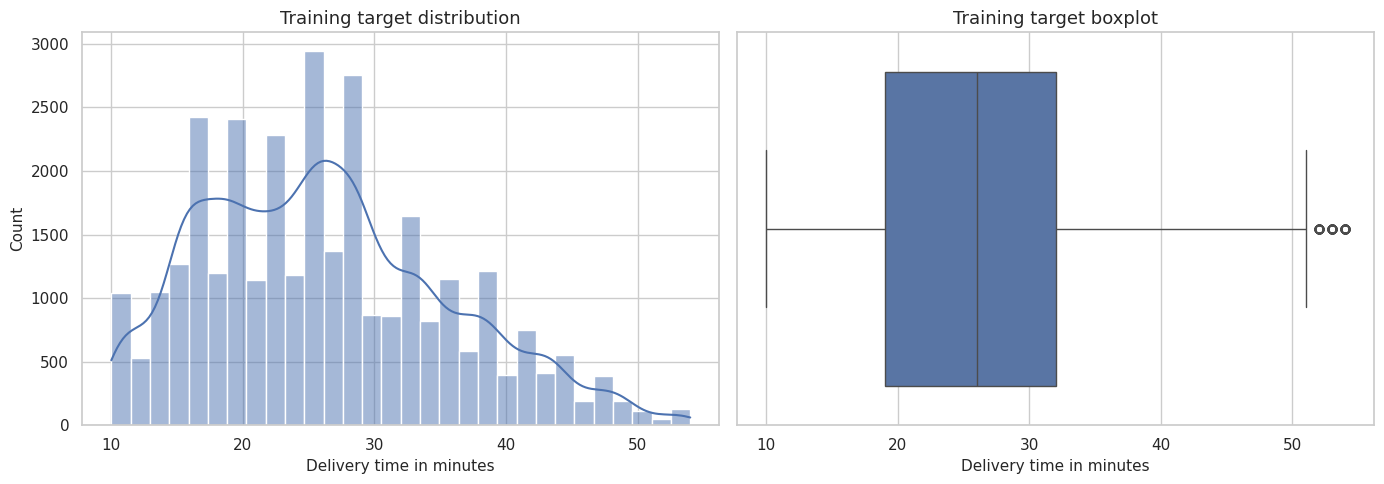

In [31]:
target_summary = train_clean[TARGET_COLUMN].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame("value")
display(target_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_clean[TARGET_COLUMN], bins=30, kde=True, ax=axes[0], color=DEFAULT_PLOT_COLOR)
axes[0].set_title("Training target distribution")
axes[0].set_xlabel("Delivery time in minutes")

sns.boxplot(x=train_clean[TARGET_COLUMN], ax=axes[1])
axes[1].set_title("Training target boxplot")
axes[1].set_xlabel("Delivery time in minutes")
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The descriptive statistics, histogram, density curve, and boxplot show the target range, central tendency, spread, skewness, and possible long-delivery tail. These patterns should guide later metric and model choices, not automatic target deletion.
</div>

In [32]:
q1 = train_clean[TARGET_COLUMN].quantile(0.25)
q3 = train_clean[TARGET_COLUMN].quantile(0.75)
iqr = q3 - q1
lower_iqr_bound = q1 - 1.5 * iqr
upper_iqr_bound = q3 + 1.5 * iqr

target_iqr_flag = ~train_clean[TARGET_COLUMN].between(lower_iqr_bound, upper_iqr_bound)
target_outlier_report = pd.DataFrame(
    {
        "metric": [
            "q1",
            "q3",
            "iqr",
            "lower_iqr_bound",
            "upper_iqr_bound",
            "rows_outside_iqr_bounds",
            "outside_rate",
        ],
        "value": [
            q1,
            q3,
            iqr,
            lower_iqr_bound,
            upper_iqr_bound,
            int(target_iqr_flag.sum()),
            float(target_iqr_flag.mean()),
        ],
    }
)
display(target_outlier_report)

print("No target rows are removed by this notebook.")

,metric,value
0,q1,19.0000
1,q3,32.0000
2,iqr,13.0000
3,lower_iqr_bound,-0.5000
4,upper_iqr_bound,51.5000
5,rows_outside_iqr_bounds,179.0000
6,outside_rate,0.0056


No target rows are removed by this notebook.


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The IQR rule is used only as a diagnostic. Long delivery times may be genuine high-impact cases, so they remain in the training data unless independent domain evidence proves they are erroneous.
</div>

In [33]:
eda_missing_columns = [
    "delivery_person_age",
    "delivery_person_ratings",
    "order_hour",
    "weather_conditions",
    "road_traffic_density",
    "multiple_deliveries",
    "festival",
    "area_type",
    "distance_km",
]

missing_target_rows = []
for column in eda_missing_columns:
    grouped = (
        train_clean.assign(is_missing=train_clean[column].isna())
        .groupby("is_missing", dropna=False)[TARGET_COLUMN]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
    )
    grouped.insert(0, "column", column)
    missing_target_rows.append(grouped)

missing_target_summary = pd.concat(missing_target_rows, ignore_index=True)
display(missing_target_summary)

,column,is_missing,count,mean,median,std
0,delivery_person_age,False,30589,26.2402,26.0000,9.3392
1,delivery_person_age,True,1320,26.4091,25.0000,9.6472
2,delivery_person_ratings,False,30514,26.2447,26.0000,9.3388
3,delivery_person_ratings,True,1395,26.3004,25.0000,9.6415
4,order_hour,False,30677,26.2454,26.0000,9.3403
5,order_hour,True,1232,26.2906,25.0000,9.6432
6,weather_conditions,False,31469,26.2437,26.0000,9.3496
7,weather_conditions,True,440,26.4932,26.0000,9.5321
8,road_traffic_density,False,31484,26.2439,26.0000,9.3500
9,road_traffic_density,True,425,26.4871,26.0000,9.5087


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
This table compares target behavior for missing and non-missing groups. Material differences support retaining missing-indicator features because missingness may carry operational information.
</div>

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_rate,unique
delivery_person_age,"30,589.0000",29.5963,5.8055,20.0000,20.0000,21.0000,25.0000,30.0000,35.0000,39.0000,39.0000,50.0000,0.0414,21
delivery_person_ratings,"30,514.0000",4.6339,0.3299,1.0000,3.5000,4.0000,4.5000,4.7000,4.9000,5.0000,5.0000,5.0000,0.0437,27
multiple_deliveries,"31,208.0000",0.7438,0.5721,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,2.0000,2.0000,3.0000,0.0220,4
distance_km,"29,133.0000",9.5804,5.5999,1.4651,1.4899,1.5320,4.6567,9.1218,13.6113,19.9163,20.8314,20.9695,0.0870,4362
latitude_difference,"29,133.0000",0.0628,0.0368,0.0100,0.0100,0.0100,0.0300,0.0600,0.0900,0.1300,0.1400,0.1400,0.0870,55
longitude_difference,"29,133.0000",0.0628,0.0368,0.0100,0.0100,0.0100,0.0300,0.0600,0.0900,0.1300,0.1400,0.1400,0.0870,29
order_hour,"30,677.0000",17.8341,4.8790,0.0000,0.0000,8.9167,15.1667,19.1667,21.5833,23.5000,23.8333,23.9167,0.0386,176
prep_time_minutes,"30,677.0000",9.9888,4.0819,5.0000,5.0000,5.0000,5.0000,10.0000,15.0000,15.0000,15.0000,15.0000,0.0386,3


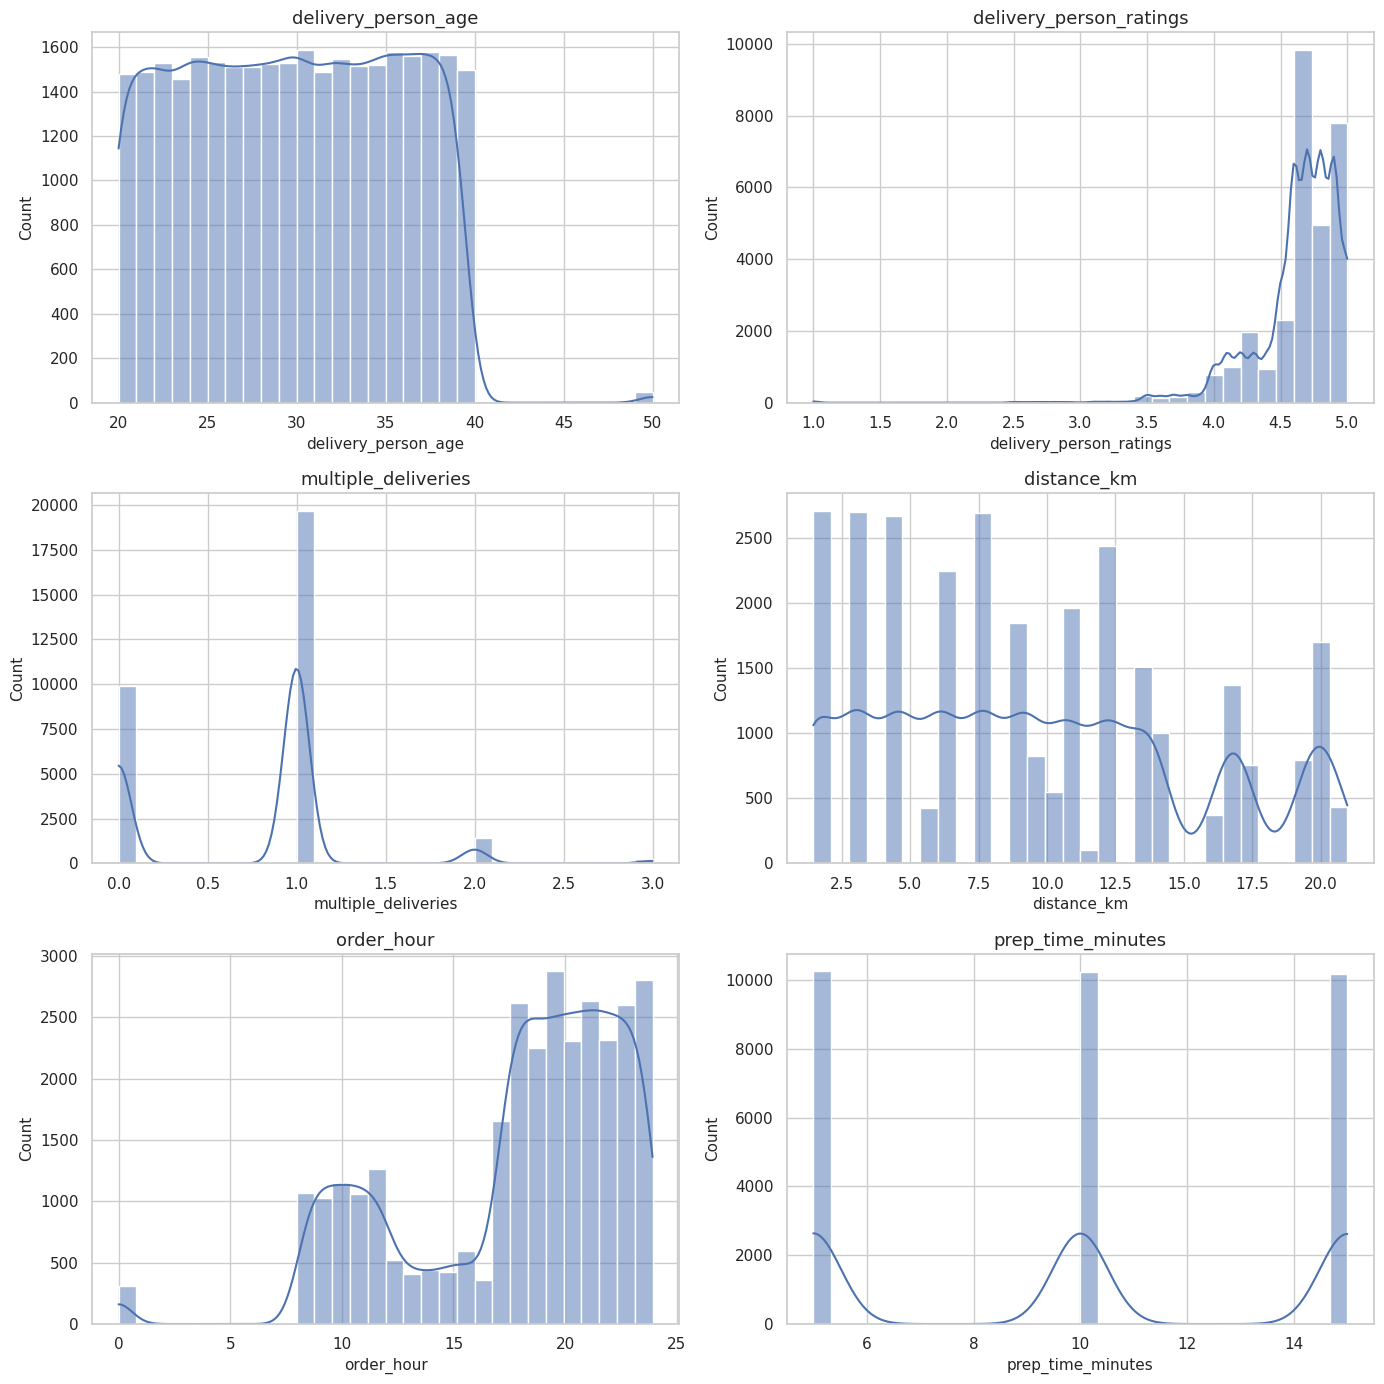

In [34]:
numeric_eda_columns = [
    "delivery_person_age",
    "delivery_person_ratings",
    "multiple_deliveries",
    "distance_km",
    "latitude_difference",
    "longitude_difference",
    "order_hour",
    "prep_time_minutes",
]

numeric_summary = train_clean[numeric_eda_columns].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T
numeric_summary["missing_rate"] = train_clean[numeric_eda_columns].isna().mean()
numeric_summary["unique"] = train_clean[numeric_eda_columns].nunique(dropna=True)
display(numeric_summary)

plot_columns = [
    "delivery_person_age",
    "delivery_person_ratings",
    "multiple_deliveries",
    "distance_km",
    "order_hour",
    "prep_time_minutes",
]
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for axis, column in zip(axes.flat, plot_columns):
    sns.histplot(train_clean[column].dropna(), bins=30, kde=True, ax=axis, color=DEFAULT_PLOT_COLOR)
    axis.set_title(column)
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The numeric summaries and distributions reveal scale, skewness, discreteness, and remaining suspicious tails. `prep_time_minutes` is included for operational EDA only and remains excluded from the main feature set.
</div>

In [35]:
categorical_eda_columns = [
    "weather_conditions",
    "road_traffic_density",
    "vehicle_condition",
    "order_type",
    "vehicle_type",
    "festival",
    "area_type",
    "city_code",
    "restaurant_code",
    "delivery_code",
    "time_of_day",
    "day_name",
]

categorical_summary_rows = []
for column in categorical_eda_columns:
    counts = train_clean[column].fillna("<MISSING>").value_counts(dropna=False)
    categorical_summary_rows.append(
        {
            "column": column,
            "unique_levels": train_clean[column].nunique(dropna=True),
            "missing_rate": train_clean[column].isna().mean(),
            "largest_level": counts.index[0] if len(counts) else None,
            "largest_level_rows": int(counts.iloc[0]) if len(counts) else 0,
            "largest_level_share": float(counts.iloc[0] / len(train_clean)) if len(counts) else np.nan,
            "smallest_level_rows": int(counts.iloc[-1]) if len(counts) else 0,
        }
    )

categorical_summary = pd.DataFrame(categorical_summary_rows)
display(categorical_summary)

for column in categorical_eda_columns:
    category_table = (
        train_clean[column]
        .fillna("<MISSING>")
        .value_counts(dropna=False)
        .rename_axis("level")
        .reset_index(name="rows")
        .assign(rate=lambda table: table["rows"] / len(train_clean))
        .head(25)
    )
    print(f"\n{column}")
    display(category_table)

,column,unique_levels,missing_rate,largest_level,largest_level_rows,largest_level_share,smallest_level_rows
0,weather_conditions,6,0.0138,Fog,5355,0.1678,440
1,road_traffic_density,4,0.0133,Low,10883,0.3411,425
2,vehicle_condition,4,0.0000,0,10566,0.3311,374
3,order_type,4,0.0000,Snack,8076,0.2531,7883
4,vehicle_type,4,0.0000,motorcycle,18519,0.5804,55
5,festival,2,0.0046,No,31146,0.9761,148
6,area_type,3,0.0257,Metropolitan,23805,0.7460,110
7,city_code,22,0.0000,JAP,2194,0.0688,691
8,restaurant_code,20,0.0000,16,1622,0.0508,1560
9,delivery_code,3,0.0000,2,11441,0.3586,9046



weather_conditions


,level,rows,rate
0,Fog,5355,0.1678
1,Stormy,5336,0.1672
2,Cloudy,5299,0.1661
3,Sandstorms,5219,0.1636
4,Windy,5165,0.1619
5,Sunny,5095,0.1597
6,<MISSING>,440,0.0138



road_traffic_density


,level,rows,rate
0,Low,10883,0.3411
1,Jam,9810,0.3074
2,Medium,7666,0.2402
3,High,3125,0.0979
4,<MISSING>,425,0.0133


...

,level,rows,rate
0,2,11441,0.3586
1,1,11422,0.3580
2,3,9046,0.2835



time_of_day


,level,rows,rate
0,Evening,15657,0.4907
1,Night,6555,0.2054
2,Morning,5569,0.1745
3,Afternoon,2896,0.0908
4,<MISSING>,1232,0.0386



day_name


,level,rows,rate
0,Thursday,5178,0.1623
1,Wednesday,4779,0.1498
2,Friday,4747,0.1488
3,Tuesday,4056,0.1271
4,Saturday,4013,0.1258
5,Monday,3961,0.1241
6,Sunday,3943,0.1236
7,<MISSING>,1232,0.0386


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
This output identifies dominant, rare, and missing categorical levels. Small groups should be interpreted with their row counts, and they should not be removed solely because their averages appear unusual.
</div>

,feature,rows,pearson,spearman
2,multiple_deliveries,31208,0.3893,0.3416
4,latitude_difference,29133,0.3251,0.3255
5,longitude_difference,29133,0.3251,0.3250
3,distance_km,29133,0.3253,0.3243
0,delivery_person_age,30589,0.3015,0.3136
1,delivery_person_ratings,30514,-0.3357,-0.2903
6,order_hour,30677,0.1862,0.1061


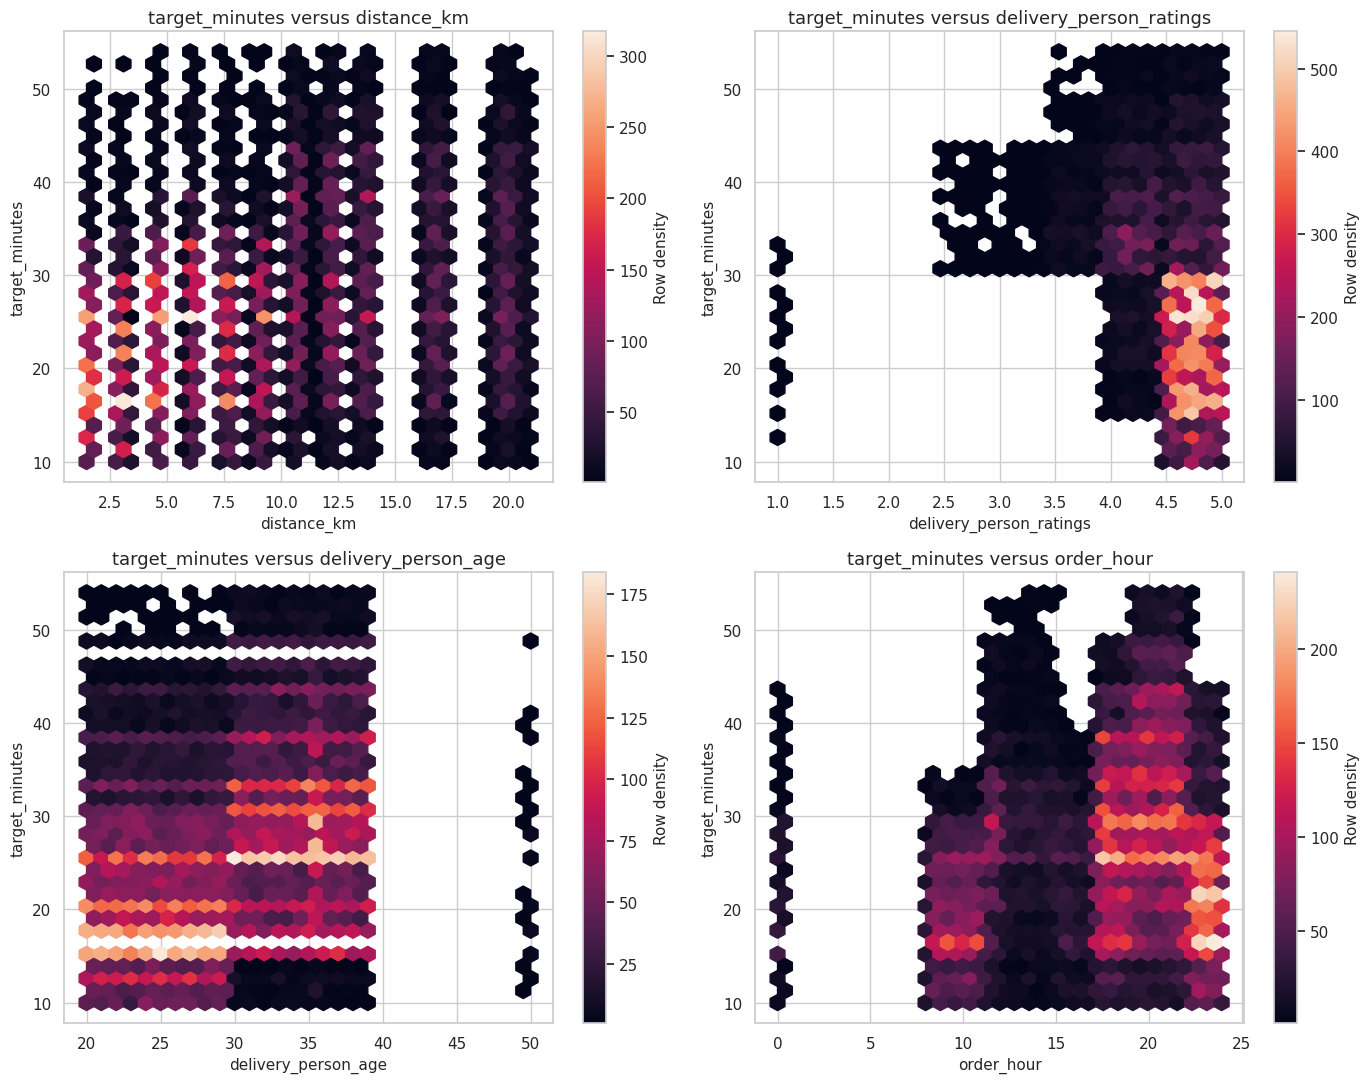

In [36]:
numeric_target_columns = [
    "delivery_person_age",
    "delivery_person_ratings",
    "multiple_deliveries",
    "distance_km",
    "latitude_difference",
    "longitude_difference",
    "order_hour",
]

correlation_rows = []
for column in numeric_target_columns:
    valid = train_clean[[column, TARGET_COLUMN]].dropna()
    correlation_rows.append(
        {
            "feature": column,
            "rows": len(valid),
            "pearson": valid[column].corr(valid[TARGET_COLUMN], method="pearson"),
            "spearman": valid[column].corr(valid[TARGET_COLUMN], method="spearman"),
        }
    )

numeric_target_correlations = pd.DataFrame(correlation_rows).sort_values(
    "spearman", key=lambda series: series.abs(), ascending=False
)
display(numeric_target_correlations)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
hexbin_columns = [
    "distance_km",
    "delivery_person_ratings",
    "delivery_person_age",
    "order_hour",
]
for axis, column in zip(axes.flat, hexbin_columns):
    valid = train_clean[[column, TARGET_COLUMN]].dropna()
    plot = axis.hexbin(valid[column], valid[TARGET_COLUMN], gridsize=30, mincnt=1)
    axis.set_title(f"{TARGET_COLUMN} versus {column}")
    axis.set_xlabel(column)
    axis.set_ylabel(TARGET_COLUMN)
    fig.colorbar(plot, ax=axis, label="Row density")
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
Pearson and Spearman values measure linear and monotonic relationships, while hexbin plots expose nonlinear structure and dense regions. Correlation alone should not determine feature removal because interactions may still be predictive.
</div>


Target summary by weather_conditions


,rows,mean,median,std,share
display_level,,,,,
Cloudy,5299,28.8064,28.0000,10.0843,0.1661
Fog,5355,28.7996,28.0000,10.1651,0.1678
<MISSING>,440,26.4932,26.0000,9.5321,0.0138
Windy,5165,25.9872,26.0000,8.5135,0.1619
Stormy,5336,25.9085,26.0000,8.4397,0.1672
Sandstorms,5219,25.8938,26.0000,8.5544,0.1636
Sunny,5095,21.8616,20.0000,8.3300,0.1597



Target summary by road_traffic_density


,rows,mean,median,std,share
display_level,,,,,
Jam,9810,31.1019,31.0000,9.8776,0.3074
High,3125,27.3488,27.0000,8.4010,0.0979
Medium,7666,26.6620,26.0000,8.5813,0.2402
<MISSING>,425,26.4871,26.0000,9.5087,0.0133
Low,10883,21.2531,20.0000,6.7963,0.3411



Target summary by vehicle_condition


...

,rows,mean,median,std,share
display_level,,,,,
Yes,615,45.5431,45.0000,3.9969,0.0193
No,31146,25.9374,25.0000,8.9869,0.9761
<MISSING>,148,11.2500,11.0000,1.2664,0.0046



Target summary by area_type


,rows,mean,median,std,share
display_level,,,,,
Semi-Urban,110,49.8727,49.0000,2.6444,0.0034
Metropolitan,23805,27.2778,26.0000,9.1472,0.7460
Urban,7173,22.9421,21.0000,8.8572,0.2248
<MISSING>,821,22.0743,21.0000,8.2823,0.0257



Target summary by time_of_day


,rows,mean,median,std,share
display_level,,,,,
Evening,15657,29.5387,29.0000,9.5933,0.4907
<MISSING>,1232,26.2906,25.0000,9.6432,0.0386
Afternoon,2896,25.7493,26.0000,8.2431,0.0908
Night,6555,22.8026,22.0000,7.6640,0.2054
Morning,5569,21.2970,20.0000,6.9525,0.1745


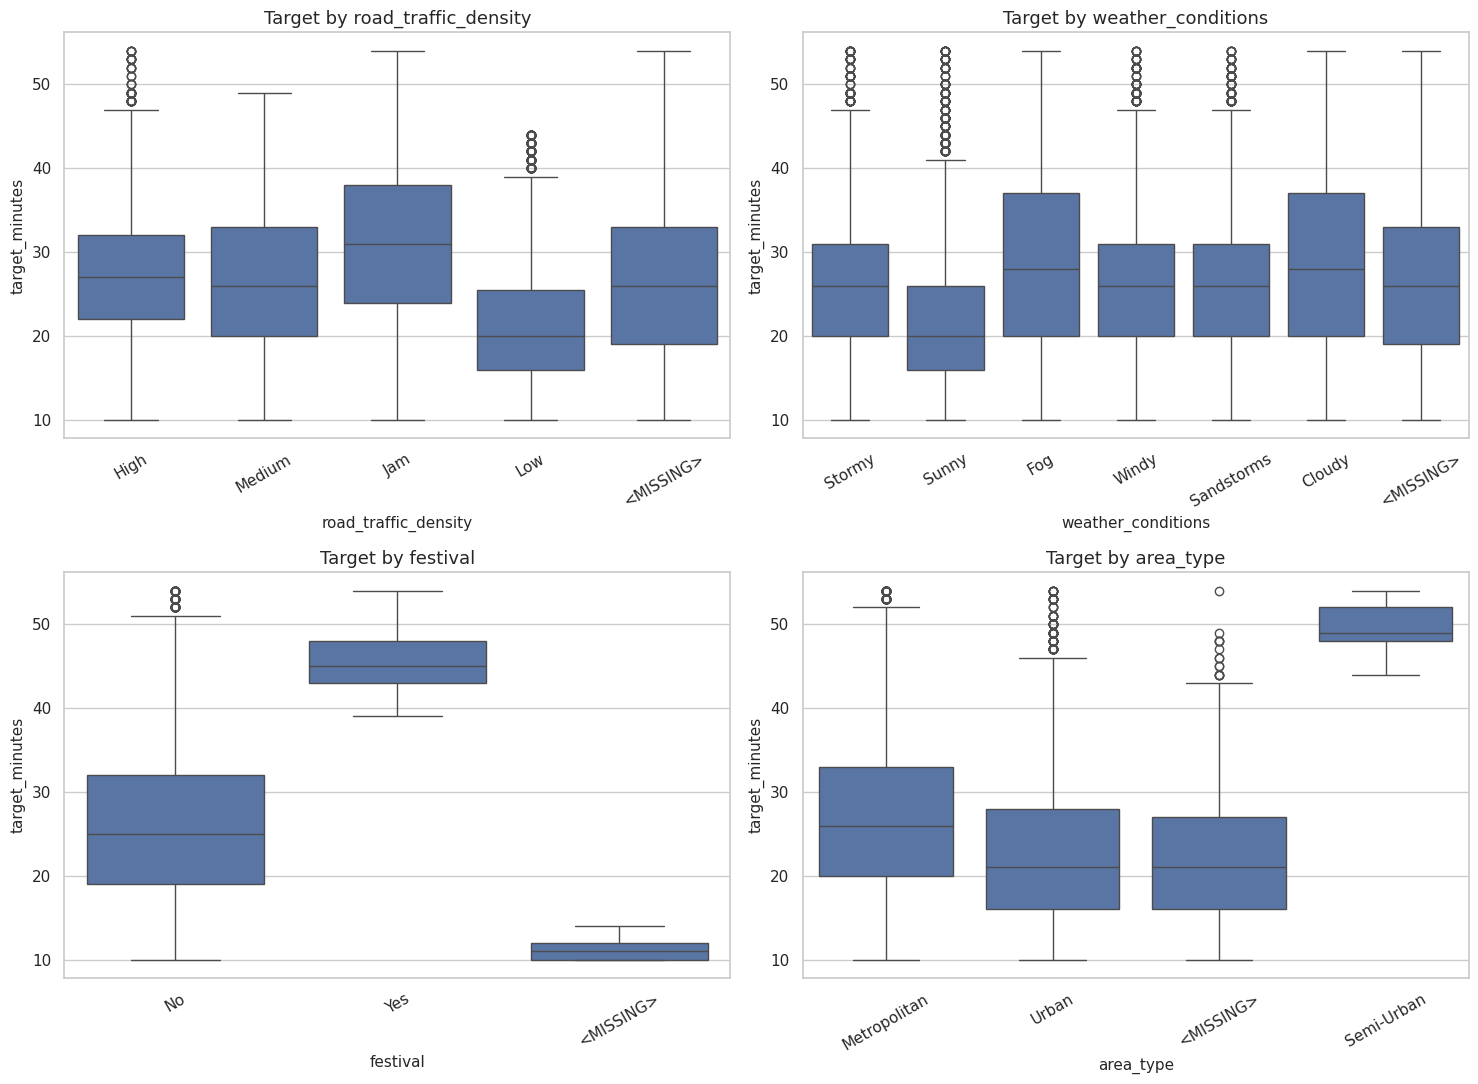

In [37]:
key_categorical_target_columns = [
    "weather_conditions",
    "road_traffic_density",
    "vehicle_condition",
    "order_type",
    "vehicle_type",
    "festival",
    "area_type",
    "time_of_day",
]

for column in key_categorical_target_columns:
    summary = (
        train_clean.assign(
            display_level=train_clean[column].fillna("<MISSING>")
        )
        .groupby("display_level", dropna=False)[TARGET_COLUMN]
        .agg(rows="size", mean="mean", median="median", std="std")
        .sort_values(["mean", "rows"], ascending=[False, False])
    )
    summary["share"] = summary["rows"] / len(train_clean)
    print(f"\nTarget summary by {column}")
    display(summary)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for axis, column in zip(
    axes.flat,
    ["road_traffic_density", "weather_conditions", "festival", "area_type"],
):
    plot_data = train_clean[[column, TARGET_COLUMN]].copy()
    plot_data[column] = plot_data[column].fillna("<MISSING>")
    sns.boxplot(data=plot_data, x=column, y=TARGET_COLUMN, ax=axis)
    axis.set_title(f"Target by {column}")
    axis.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
Category-level counts, means, medians, variability, and boxplots show how delivery time changes across operational segments. The row count must be considered whenever a rare category has an extreme mean.
</div>

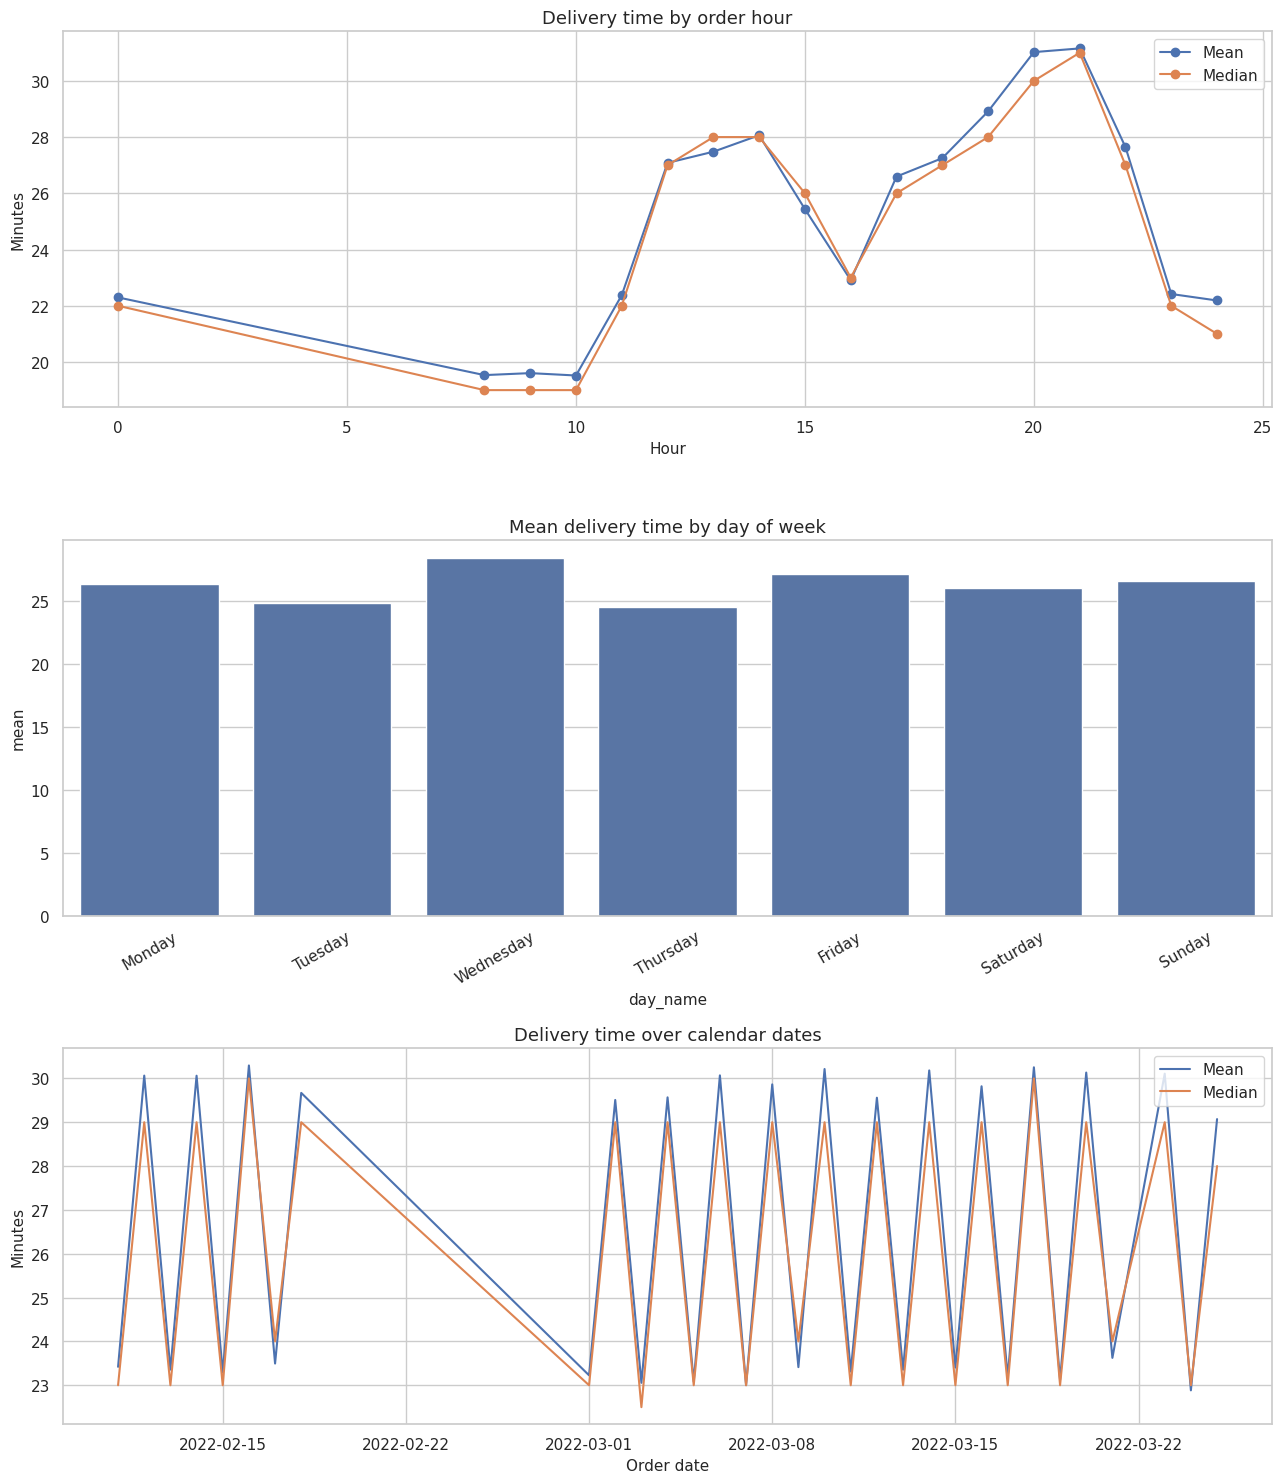

In [38]:
hourly_target = (
    train_clean.assign(order_hour_integer=train_clean["order_hour"].round().astype("Int64"))
    .dropna(subset=["order_hour_integer"])
    .groupby("order_hour_integer")[TARGET_COLUMN]
    .agg(rows="size", mean="mean", median="median")
    .reset_index()
)

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_target = (
    train_clean.assign(
        day_name=pd.Categorical(train_clean["day_name"], categories=day_order, ordered=True)
    )
    .dropna(subset=["day_name"])
    .groupby("day_name", observed=False)[TARGET_COLUMN]
    .agg(rows="size", mean="mean", median="median")
    .reset_index()
)

daily_target = (
    train_clean.dropna(subset=["order_date"])
    .groupby("order_date")[TARGET_COLUMN]
    .agg(rows="size", mean="mean", median="median")
    .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(13, 15))
axes[0].plot(hourly_target["order_hour_integer"], hourly_target["mean"], marker="o", label="Mean")
axes[0].plot(hourly_target["order_hour_integer"], hourly_target["median"], marker="o", label="Median")
axes[0].set_title("Delivery time by order hour")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Minutes")
axes[0].legend()

sns.barplot(data=day_target, x="day_name", y="mean", ax=axes[1], color=DEFAULT_PLOT_COLOR)
axes[1].set_title("Mean delivery time by day of week")
axes[1].tick_params(axis="x", rotation=30)

axes[2].plot(daily_target["order_date"], daily_target["mean"], label="Mean")
axes[2].plot(daily_target["order_date"], daily_target["median"], label="Median")
axes[2].set_title("Delivery time over calendar dates")
axes[2].set_xlabel("Order date")
axes[2].set_ylabel("Minutes")
axes[2].legend()
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
Temporal plots reveal peak-hour effects, day-of-week differences, and date-level shifts. A visible trend across dates supports the chronological validation strategy and warns against relying only on random splits.
</div>

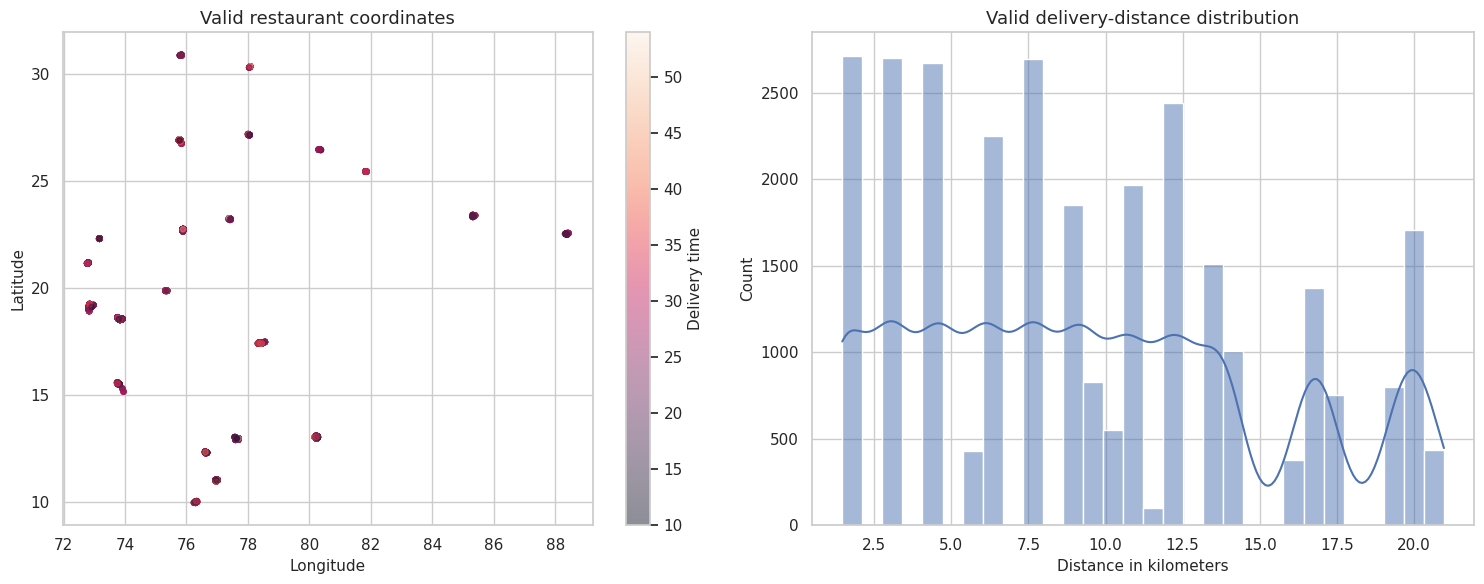

,rows,mean,median
distance_bin,,,
"(1.4640000000000002, 2.98]",2914,21.4828,21.0000
"(2.98, 4.494]",2914,21.6359,21.0000
"(4.494, 6.05]",2915,24.1647,24.0000
"(6.05, 7.573]",2917,25.2900,26.0000
"(7.573, 9.122]",2917,23.6500,24.0000
"(9.122, 10.723]",2910,26.4986,26.0000
"(10.723, 12.351]",2908,30.1107,29.0000
"(12.351, 13.989]",2913,29.8970,29.0000
"(13.989, 19.043]",2912,29.9938,29.0000


In [39]:
valid_geo = train_clean.dropna(
    subset=[
        "restaurant_latitude",
        "restaurant_longitude",
        "delivery_location_latitude",
        "delivery_location_longitude",
        "distance_km",
    ]
).copy()

sample_size = min(6000, len(valid_geo))
geo_sample = valid_geo.sample(sample_size, random_state=RANDOM_STATE) if sample_size else valid_geo

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
scatter = axes[0].scatter(
    geo_sample["restaurant_longitude"],
    geo_sample["restaurant_latitude"],
    c=geo_sample[TARGET_COLUMN],
    alpha=0.45,
    s=14,
)
axes[0].set_title("Valid restaurant coordinates")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
plt.colorbar(scatter, ax=axes[0], label="Delivery time")

sns.histplot(valid_geo["distance_km"], bins=30, kde=True, ax=axes[1], color=DEFAULT_PLOT_COLOR)
axes[1].set_title("Valid delivery-distance distribution")
axes[1].set_xlabel("Distance in kilometers")
plt.tight_layout()
plt.show()

if valid_geo["distance_km"].nunique() >= 5:
    distance_bins = pd.qcut(valid_geo["distance_km"], q=10, duplicates="drop")
    distance_target = (
        valid_geo.assign(distance_bin=distance_bins)
        .groupby("distance_bin", observed=False)[TARGET_COLUMN]
        .agg(rows="size", mean="mean", median="median")
    )
    display(distance_target)

<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
Only valid coordinates are mapped, preventing zero placeholders from appearing as real locations. The distance distribution and quantile-bin target summary show whether longer routes have a consistent operational effect.
</div>

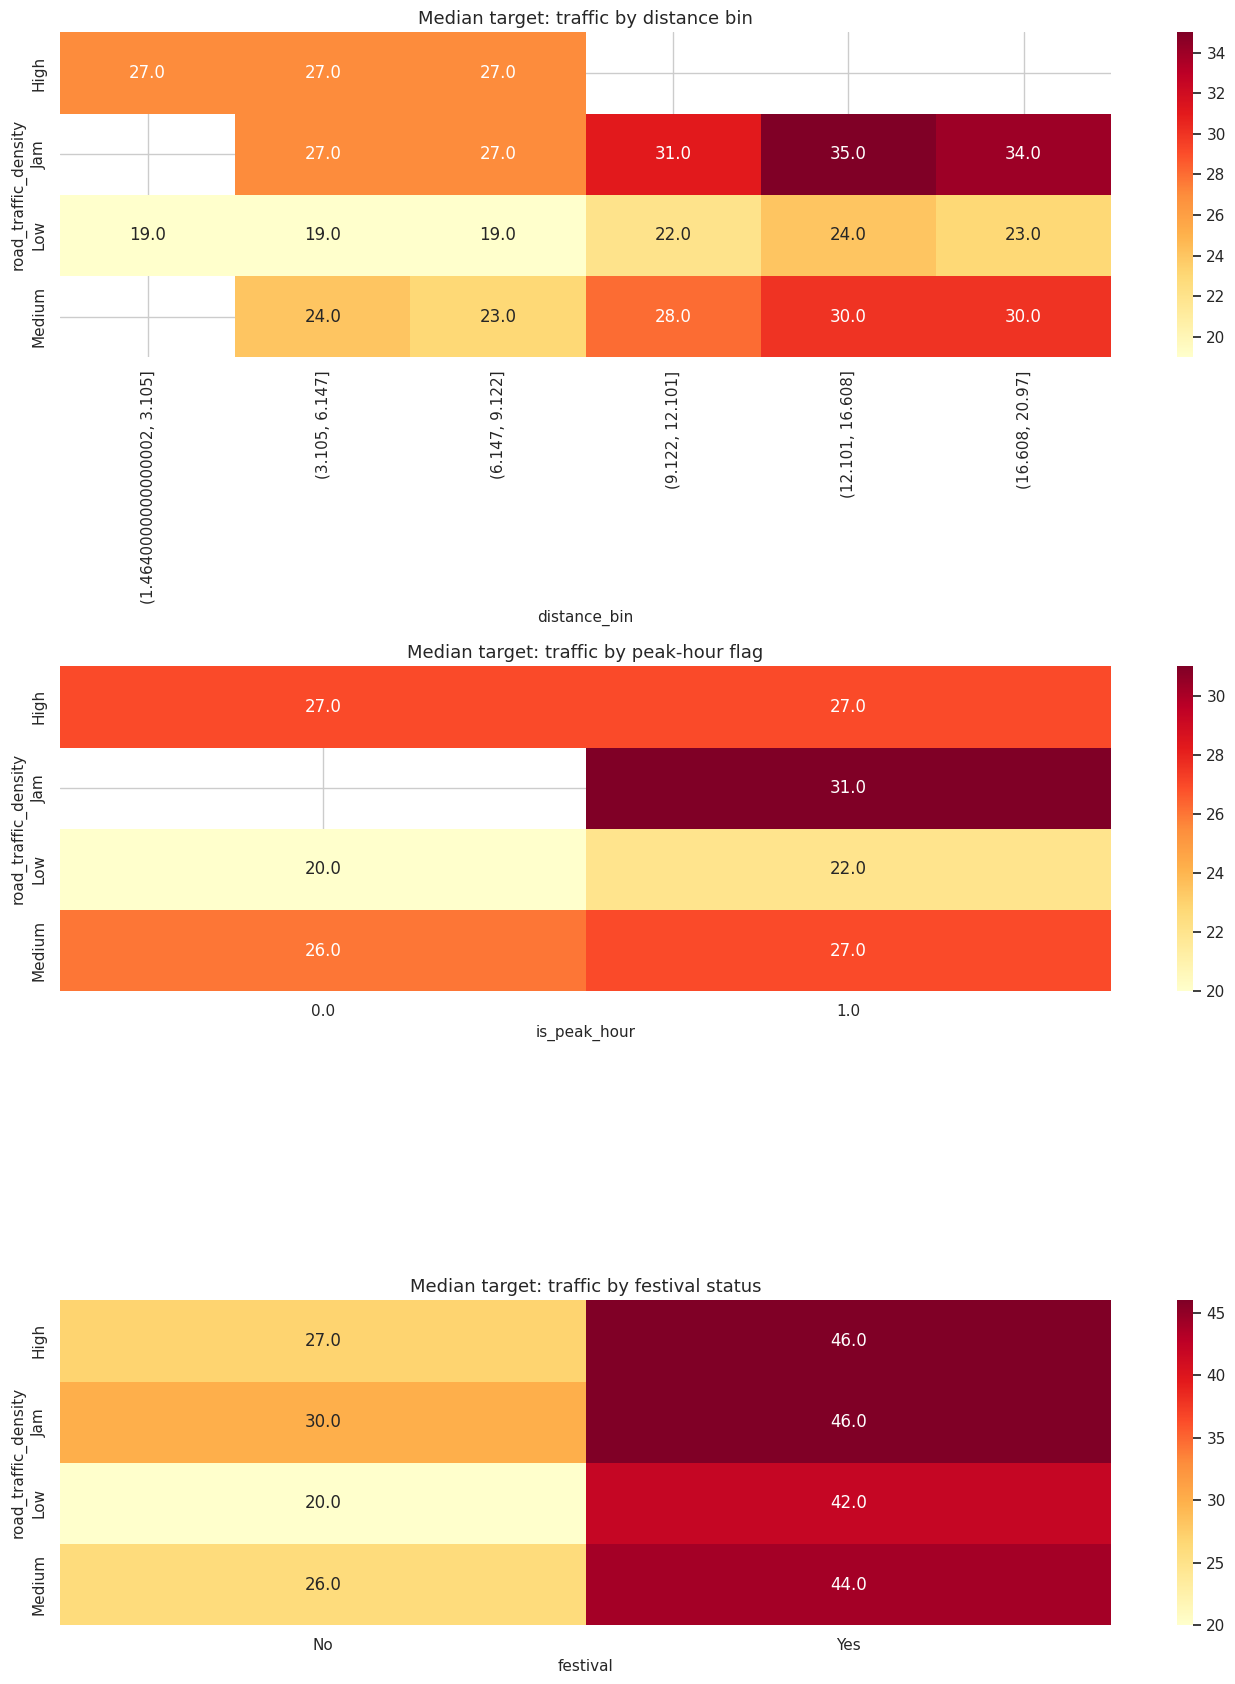

In [40]:
interaction_frame = train_clean.copy()
interaction_frame["distance_bin"] = pd.qcut(
    interaction_frame["distance_km"], q=6, duplicates="drop"
)

traffic_distance_pivot = interaction_frame.pivot_table(
    index="road_traffic_density",
    columns="distance_bin",
    values=TARGET_COLUMN,
    aggfunc="median",
    observed=False,
)

peak_traffic_pivot = interaction_frame.pivot_table(
    index="road_traffic_density",
    columns="is_peak_hour",
    values=TARGET_COLUMN,
    aggfunc="median",
    observed=False,
)

festival_traffic_pivot = interaction_frame.pivot_table(
    index="road_traffic_density",
    columns="festival",
    values=TARGET_COLUMN,
    aggfunc="median",
    observed=False,
)

fig, axes = plt.subplots(3, 1, figsize=(14, 17))
sns.heatmap(traffic_distance_pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[0])
axes[0].set_title("Median target: traffic by distance bin")

sns.heatmap(peak_traffic_pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Median target: traffic by peak-hour flag")

sns.heatmap(festival_traffic_pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[2])
axes[2].set_title("Median target: traffic by festival status")
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The interaction heatmaps test whether distance, peak periods, festivals, and traffic jointly affect delivery time. Strong non-additive patterns justify explicit interaction features or nonlinear models later.
</div>

## 9. Compare feature drift across train, validation, and test

In [41]:
def numeric_population_stability_index(
    train_series: pd.Series,
    comparison_series: pd.Series,
    bins: int = 10,
) -> float:
    """Calculate PSI using quantile edges learned from the training series."""
    train_values = pd.to_numeric(train_series, errors="coerce").dropna()
    comparison_values = pd.to_numeric(comparison_series, errors="coerce").dropna()
    if train_values.empty or comparison_values.empty:
        return np.nan

    quantiles = np.linspace(0, 1, bins + 1)
    edges = np.unique(train_values.quantile(quantiles).to_numpy())
    if len(edges) < 3:
        return 0.0
    edges[0] = -np.inf
    edges[-1] = np.inf

    train_counts = pd.cut(train_values, bins=edges, include_lowest=True).value_counts(sort=False)
    comparison_counts = pd.cut(comparison_values, bins=edges, include_lowest=True).value_counts(sort=False)

    train_distribution = train_counts / train_counts.sum()
    comparison_distribution = comparison_counts / comparison_counts.sum()
    epsilon = 1e-6
    train_distribution = train_distribution.clip(lower=epsilon)
    comparison_distribution = comparison_distribution.clip(lower=epsilon)

    return float(
        ((comparison_distribution - train_distribution)
         * np.log(comparison_distribution / train_distribution)).sum()
    )


def categorical_jensen_shannon_distance(
    train_series: pd.Series,
    comparison_series: pd.Series,
) -> float:
    train_values = train_series.astype("string").fillna("<MISSING>")
    comparison_values = comparison_series.astype("string").fillna("<MISSING>")
    categories = sorted(set(train_values.unique()).union(comparison_values.unique()))
    train_distribution = train_values.value_counts(normalize=True).reindex(categories, fill_value=0)
    comparison_distribution = comparison_values.value_counts(normalize=True).reindex(categories, fill_value=0)
    return float(jensenshannon(train_distribution, comparison_distribution, base=2))

<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
Two drift metrics are defined without using target values. Numeric PSI uses training-derived bins, while categorical Jensen-Shannon distance compares aligned category distributions.
</div>

In [42]:
drift_numeric_columns = [
    "delivery_person_age",
    "delivery_person_ratings",
    "multiple_deliveries",
    "distance_km",
    "order_hour",
]
drift_categorical_columns = [
    "weather_conditions",
    "road_traffic_density",
    "vehicle_condition",
    "order_type",
    "vehicle_type",
    "festival",
    "area_type",
    "city_code",
]

numeric_drift_rows = []
for column in drift_numeric_columns:
    numeric_drift_rows.extend(
        [
            {
                "feature": column,
                "type": "numeric",
                "comparison": "validation",
                "drift_metric": "PSI",
                "value": numeric_population_stability_index(
                    train_clean[column], validation_clean[column]
                ),
            },
            {
                "feature": column,
                "type": "numeric",
                "comparison": "test",
                "drift_metric": "PSI",
                "value": numeric_population_stability_index(
                    train_clean[column], test_clean[column]
                ),
            },
        ]
    )

categorical_drift_rows = []
for column in drift_categorical_columns:
    categorical_drift_rows.extend(
        [
            {
                "feature": column,
                "type": "categorical",
                "comparison": "validation",
                "drift_metric": "Jensen-Shannon distance",
                "value": categorical_jensen_shannon_distance(
                    train_clean[column], validation_clean[column]
                ),
            },
            {
                "feature": column,
                "type": "categorical",
                "comparison": "test",
                "drift_metric": "Jensen-Shannon distance",
                "value": categorical_jensen_shannon_distance(
                    train_clean[column], test_clean[column]
                ),
            },
        ]
    )

drift_report = pd.DataFrame(numeric_drift_rows + categorical_drift_rows).sort_values(
    "value", ascending=False
)
display(drift_report)

,feature,type,comparison,drift_metric,value
25,city_code,categorical,test,Jensen-Shannon distance,0.3522
24,city_code,categorical,validation,Jensen-Shannon distance,0.3522
12,road_traffic_density,categorical,validation,Jensen-Shannon distance,0.0171
18,vehicle_type,categorical,validation,Jensen-Shannon distance,0.0158
11,weather_conditions,categorical,test,Jensen-Shannon distance,0.0135
6,distance_km,numeric,validation,PSI,0.0127
16,order_type,categorical,validation,Jensen-Shannon distance,0.0121
23,area_type,categorical,test,Jensen-Shannon distance,0.0110
22,area_type,categorical,validation,Jensen-Shannon distance,0.0110
14,vehicle_condition,categorical,validation,Jensen-Shannon distance,0.0103


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The drift report ranks feature-distribution changes between training and later periods without inspecting validation or test targets. Large values indicate that later model evaluation should include segment-level error analysis and possibly retraining plans.
</div>

## 10. Add hypothesis-driven interaction features

In [43]:
TRAFFIC_SEVERITY_MAP = {"Low": 0.0, "Medium": 1.0, "High": 2.0, "Jam": 3.0}


def add_hypothesis_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Create a small, interpretable set of EDA-motivated interactions."""
    output = frame.copy()
    output["traffic_severity"] = output["road_traffic_density"].map(
        TRAFFIC_SEVERITY_MAP
    ).astype(float)

    festival_is_yes = output["festival"].eq("Yes").fillna(False).to_numpy(dtype=bool)
    festival_is_no = output["festival"].eq("No").fillna(False).to_numpy(dtype=bool)
    output["festival_yes_flag"] = np.select(
        [festival_is_yes, festival_is_no],
        [1.0, 0.0],
        default=np.nan,
    )
    output["distance_x_traffic"] = output["distance_km"] * output["traffic_severity"]
    output["distance_x_multiple_deliveries"] = (
        output["distance_km"] * output["multiple_deliveries"]
    )
    output["peak_x_traffic"] = output["is_peak_hour"] * output["traffic_severity"]
    output["festival_x_traffic"] = output["festival_yes_flag"] * output["traffic_severity"]

    weather_text = output["weather_conditions"].astype("string").fillna("Unknown")
    vehicle_text = output["vehicle_type"].astype("string").fillna("Unknown")
    area_text = output["area_type"].astype("string").fillna("Unknown")
    traffic_text = output["road_traffic_density"].astype("string").fillna("Unknown")
    output["weather_vehicle_interaction"] = weather_text + "__" + vehicle_text
    output["area_traffic_interaction"] = area_text + "__" + traffic_text

    return output


train_features = add_hypothesis_features(train_clean)
validation_features = add_hypothesis_features(validation_clean)
test_features = add_hypothesis_features(test_clean)

new_hypothesis_features = [
    "traffic_severity",
    "festival_yes_flag",
    "distance_x_traffic",
    "distance_x_multiple_deliveries",
    "peak_x_traffic",
    "festival_x_traffic",
    "weather_vehicle_interaction",
    "area_traffic_interaction",
]
display(train_features[new_hypothesis_features].head(10))

,traffic_severity,festival_yes_flag,distance_x_traffic,distance_x_multiple_deliveries,peak_x_traffic,festival_x_traffic,weather_vehicle_interaction,area_traffic_interaction
0,2.0000,0.0000,3.0273,0.0000,2.0000,0.0000,Stormy__motorcycle,Metropolitan__High
1,1.0000,0.0000,9.0813,0.0000,0.0000,0.0000,Sunny__motorcycle,Metropolitan__Medium
2,2.0000,0.0000,11.9843,0.0000,0.0000,0.0000,Stormy__motorcycle,Urban__High
3,3.0000,0.0000,NaN,NaN,3.0000,0.0000,Fog__motorcycle,Metropolitan__Jam
4,0.0000,0.0000,NaN,NaN,0.0000,0.0000,Windy__scooter,Urban__Low
5,0.0000,0.0000,0.0000,7.4902,0.0000,0.0000,Sandstorms__motorcycle,Metropolitan__Low
6,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,Cloudy__motorcycle,Urban__Low
7,1.0000,0.0000,9.1577,0.0000,1.0000,0.0000,Sunny__scooter,Urban__Medium
8,1.0000,0.0000,9.3636,9.3636,0.0000,0.0000,Windy__motorcycle,Metropolitan__Medium
9,1.0000,0.0000,8.9531,0.0000,0.0000,0.0000,Stormy__scooter,Metropolitan__Medium


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
A limited set of interpretable interactions is added consistently to every split. The features encode specific hypotheses from EDA instead of generating an uncontrolled combinatorial feature set.
</div>

## 11. Define the main feature set and perform leakage checks

In [44]:
quality_numeric_features = [
    "age_invalid_flag",
    "age_suspect_flag",
    "rating_invalid_flag",
    "multiple_deliveries_invalid_flag",
    "vehicle_condition_invalid_flag",
    "vehicle_condition_suspect_flag",
    "order_date_parse_failed_flag",
    "order_time_parse_failed_flag",
    "time_ordered_missing_flag",
    "gps_zero_flag",
    "gps_sign_repaired_flag",
    "gps_out_of_region_flag",
    "gps_invalid_flag",
    "distance_missing_flag",
    "distance_suspect_flag",
    "delivery_id_parse_failed_flag",
    "delivery_person_age_missing_flag",
    "delivery_person_ratings_missing_flag",
    "weather_conditions_missing_flag",
    "road_traffic_density_missing_flag",
    "multiple_deliveries_missing_flag",
    "festival_missing_flag",
    "area_type_missing_flag",
    "special_record_flag",
]

candidate_numeric_features = [
    "delivery_person_age",
    "delivery_person_ratings",
    "multiple_deliveries",
    "distance_km",
    "latitude_difference",
    "longitude_difference",
    "order_hour",
    "order_minute_of_day",
    "day_of_week",
    "month",
    "is_weekend",
    "is_lunch_peak",
    "is_dinner_peak",
    "is_peak_hour",
    "order_hour_sin",
    "order_hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "traffic_severity",
    "festival_yes_flag",
    "distance_x_traffic",
    "distance_x_multiple_deliveries",
    "peak_x_traffic",
    "festival_x_traffic",
] + quality_numeric_features

candidate_categorical_features = [
    "weather_conditions",
    "road_traffic_density",
    "vehicle_condition",
    "order_type",
    "vehicle_type",
    "festival",
    "area_type",
    "city_code",
    "restaurant_code",
    "delivery_code",
    "time_of_day",
    "weather_vehicle_interaction",
    "area_traffic_interaction",
]

forbidden_main_features = {
    "order_id",
    "delivery_person_id",
    "source_split",
    "source_row_number",
    "order_date",
    "time_ordered",
    "time_order_picked",
    "order_datetime",
    "pickup_datetime",
    "pickup_hour",
    "prep_time_minutes",
    "restaurant_latitude",
    "restaurant_longitude",
    "delivery_location_latitude",
    "delivery_location_longitude",
    TARGET_COLUMN,
}

candidate_feature_set = set(candidate_numeric_features + candidate_categorical_features)
leakage_overlap = sorted(candidate_feature_set.intersection(forbidden_main_features))
missing_candidates = sorted(candidate_feature_set.difference(train_features.columns))

assert not leakage_overlap, f"Forbidden features found: {leakage_overlap}"
assert not missing_candidates, f"Candidate features are missing: {missing_candidates}"

feature_manifest_preview = pd.DataFrame(
    {
        "group": ["numeric", "categorical", "forbidden", "post_pickup_only"],
        "count": [
            len(candidate_numeric_features),
            len(candidate_categorical_features),
            len(forbidden_main_features),
            2,
        ],
        "examples": [
            candidate_numeric_features[:8],
            candidate_categorical_features[:8],
            sorted(forbidden_main_features)[:8],
            ["pickup_hour", "prep_time_minutes"],
        ],
    }
)
display(feature_manifest_preview)
print("Main feature leakage audit passed.")

,group,count,examples
0,numeric,48,"[delivery_person_age, delivery_person_ratings,..."
1,categorical,13,"[weather_conditions, road_traffic_density, veh..."
2,forbidden,16,"[delivery_location_latitude, delivery_location..."
3,post_pickup_only,2,"[pickup_hour, prep_time_minutes]"


Main feature leakage audit passed.


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The candidate main feature set passes a strict availability and leakage audit. Raw identifiers, raw timestamps, pickup-derived information, raw coordinates, provenance, and the target are absent from model inputs.
</div>

In [45]:
def feature_quality_table(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    rows = []
    for column in columns:
        series = frame[column]
        counts = series.astype("string").fillna("<MISSING>").value_counts(dropna=False)
        dominant_share = float(counts.iloc[0] / len(series)) if len(counts) else np.nan
        rows.append(
            {
                "feature": column,
                "dtype": str(series.dtype),
                "missing_rate": float(series.isna().mean()),
                "unique_non_null": int(series.nunique(dropna=True)),
                "dominant_share": dominant_share,
                "constant": bool(series.nunique(dropna=False) <= 1),
                "near_constant_99_9": bool(dominant_share >= 0.999),
            }
        )
    return pd.DataFrame(rows)


candidate_feature_quality = feature_quality_table(
    train_features, candidate_numeric_features + candidate_categorical_features
).sort_values(["constant", "near_constant_99_9", "missing_rate"], ascending=False)

display(candidate_feature_quality)

,feature,dtype,missing_rate,unique_non_null,dominant_share,constant,near_constant_99_9
27,multiple_deliveries_invalid_flag,int8,0.0000,1,1.0000,True,True
28,vehicle_condition_invalid_flag,int8,0.0000,1,1.0000,True,True
30,order_date_parse_failed_flag,int8,0.0000,1,1.0000,True,True
31,order_time_parse_failed_flag,int8,0.0000,1,1.0000,True,True
38,distance_suspect_flag,int8,0.0000,1,1.0000,True,True
39,delivery_id_parse_failed_flag,int8,0.0000,1,1.0000,True,True
24,age_invalid_flag,int8,0.0000,2,0.9992,False,True
21,distance_x_multiple_deliveries,float64,0.1067,5482,0.2826,False,False
20,distance_x_traffic,float64,0.0992,6848,0.3107,False,False
3,distance_km,float64,0.0870,4362,0.0870,False,False


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The feature-quality table identifies constant, nearly constant, highly missing, and low-cardinality candidates using training data only. Constant columns can be removed safely before model training, while near-constant quality flags should be retained unless validation proves they add no value.
</div>

In [46]:
constant_features = candidate_feature_quality.loc[
    candidate_feature_quality["constant"], "feature"
].tolist()

manual_redundancy_drops = [
    "order_minute_of_day",  # Exact linear rescaling of order_hour.
]

selected_numeric_features = [
    feature
    for feature in candidate_numeric_features
    if feature not in constant_features and feature not in manual_redundancy_drops
]
selected_categorical_features = [
    feature
    for feature in candidate_categorical_features
    if feature not in constant_features
]
selected_feature_columns = selected_numeric_features + selected_categorical_features

selection_summary = pd.DataFrame(
    {
        "item": [
            "candidate_numeric",
            "candidate_categorical",
            "constant_removed",
            "manual_redundancy_removed",
            "selected_numeric",
            "selected_categorical",
            "selected_total",
        ],
        "count": [
            len(candidate_numeric_features),
            len(candidate_categorical_features),
            len(constant_features),
            len(manual_redundancy_drops),
            len(selected_numeric_features),
            len(selected_categorical_features),
            len(selected_feature_columns),
        ],
        "details": [
            None,
            None,
            constant_features,
            manual_redundancy_drops,
            None,
            None,
            None,
        ],
    }
)
display(selection_summary)

,item,count,details
0,candidate_numeric,48,None
1,candidate_categorical,13,None
2,constant_removed,6,"[multiple_deliveries_invalid_flag, vehicle_con..."
3,manual_redundancy_removed,1,[order_minute_of_day]
4,selected_numeric,41,None
5,selected_categorical,13,None
6,selected_total,54,None


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
Automatic removal is deliberately conservative: only constant features and the exact rescaling `order_minute_of_day` are removed. Other correlated or low-information features remain candidates until model-based ablation can measure their validation impact.
</div>

In [47]:
correlation_frame = train_features[selected_numeric_features].apply(
    pd.to_numeric, errors="coerce"
)
absolute_correlation = correlation_frame.corr(method="spearman").abs()
upper_triangle = absolute_correlation.where(
    np.triu(np.ones(absolute_correlation.shape), k=1).astype(bool)
)

high_correlation_pairs = (
    upper_triangle.stack()
    .rename("absolute_spearman")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
    .query("absolute_spearman >= 0.90")
    .sort_values("absolute_spearman", ascending=False)
)
display(high_correlation_pairs)

,feature_1,feature_2,absolute_spearman
622,gps_out_of_region_flag,gps_invalid_flag,1.0000
623,gps_out_of_region_flag,distance_missing_flag,1.0000
632,gps_invalid_flag,distance_missing_flag,1.0000
601,gps_zero_flag,gps_invalid_flag,1.0000
600,gps_zero_flag,gps_out_of_region_flag,1.0000
585,vehicle_condition_suspect_flag,special_record_flag,1.0000
541,age_suspect_flag,rating_invalid_flag,1.0000
602,gps_zero_flag,distance_missing_flag,1.0000
144,latitude_difference,longitude_difference,0.9955
112,distance_km,longitude_difference,0.9942


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The high-correlation table highlights redundant numeric representations without removing them automatically. Later linear models may require additional reduction, while tree-based models may tolerate or exploit some of these relationships.
</div>

## 12. Rank feature relevance with training-only mutual information

,feature,mutual_information,feature_type
53,area_traffic_interaction,0.1542,categorical
1,delivery_person_ratings,0.1536,numeric
19,distance_x_traffic,0.1493,numeric
20,distance_x_multiple_deliveries,0.1430,numeric
6,order_hour,0.1283,numeric
42,road_traffic_density,0.1227,categorical
17,traffic_severity,0.1217,numeric
2,multiple_deliveries,0.1156,numeric
14,order_hour_cos,0.1086,numeric
13,order_hour_sin,0.1066,numeric


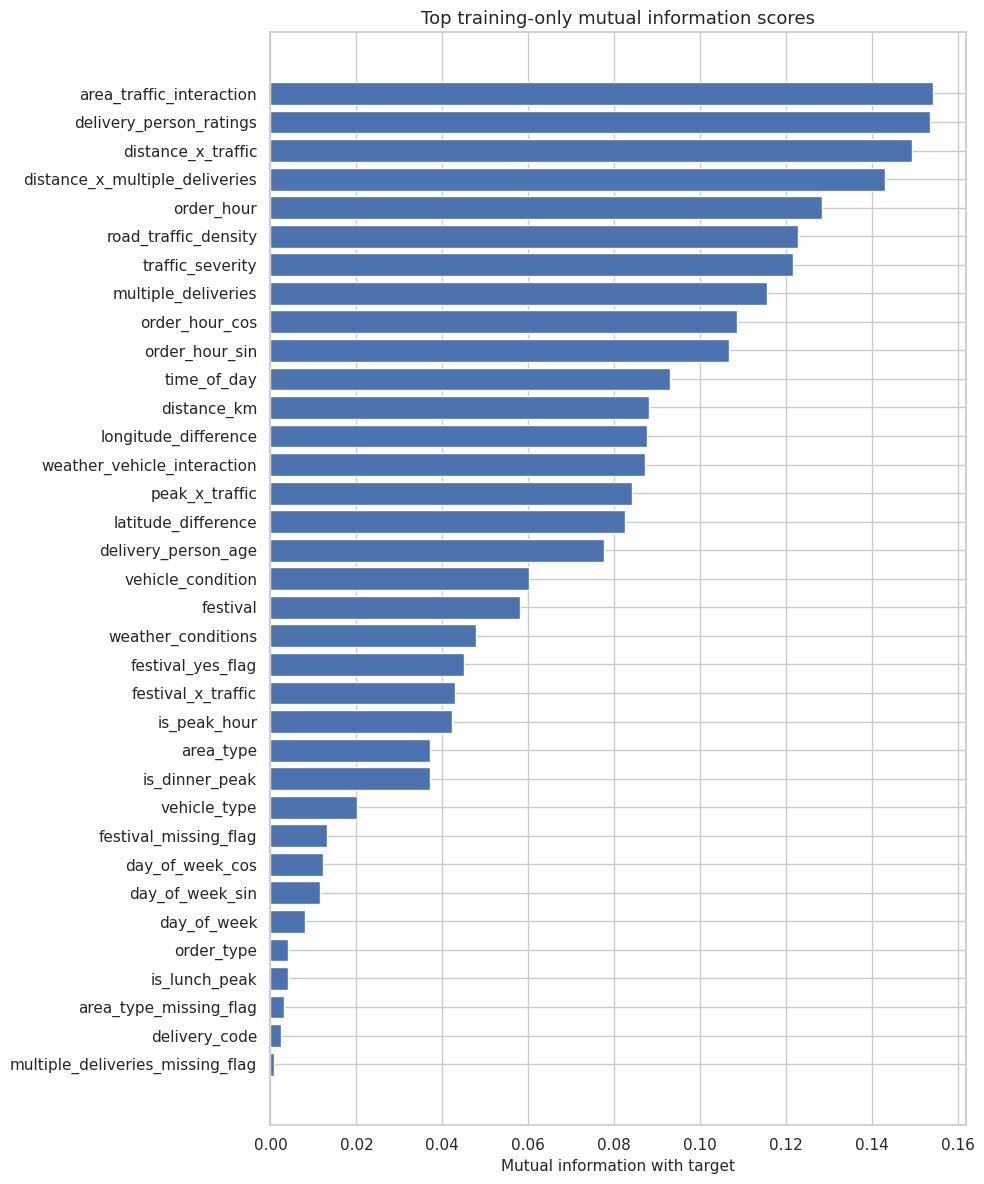

In [48]:
mi_numeric_imputer = SimpleImputer(strategy="median")
mi_categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        (
            "ordinal",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
                encoded_missing_value=-1,
            ),
        ),
    ]
)

mi_numeric_frame = train_features[selected_numeric_features].apply(
    pd.to_numeric, errors="coerce"
)
mi_categorical_frame = train_features[selected_categorical_features].copy()
for column in selected_categorical_features:
    mi_categorical_frame[column] = (
        mi_categorical_frame[column]
        .astype("object")
        .where(mi_categorical_frame[column].notna(), np.nan)
    )

mi_numeric_matrix = mi_numeric_imputer.fit_transform(mi_numeric_frame)
mi_categorical_matrix = mi_categorical_pipeline.fit_transform(mi_categorical_frame)
mi_matrix = np.hstack([mi_numeric_matrix, mi_categorical_matrix])

numeric_discrete_mask = [
    train_features[column].nunique(dropna=True) <= 20
    for column in selected_numeric_features
]
discrete_feature_mask = np.array(
    numeric_discrete_mask + [True] * len(selected_categorical_features),
    dtype=bool,
)

mi_scores = mutual_info_regression(
    mi_matrix,
    train_features[TARGET_COLUMN].to_numpy(),
    discrete_features=discrete_feature_mask,
    random_state=RANDOM_STATE,
)

mutual_information_report = pd.DataFrame(
    {
        "feature": selected_feature_columns,
        "mutual_information": mi_scores,
        "feature_type": [
            "numeric" if feature in selected_numeric_features else "categorical"
            for feature in selected_feature_columns
        ],
    }
).sort_values("mutual_information", ascending=False)

display(mutual_information_report)

plt.figure(figsize=(10, 12))
plot_report = mutual_information_report.head(35).sort_values("mutual_information")
plt.barh(plot_report["feature"], plot_report["mutual_information"])
plt.title("Top training-only mutual information scores")
plt.xlabel("Mutual information with target")
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
Mutual information ranks both linear and nonlinear univariate relevance using the training split only. A low score is a model-selection candidate, not an automatic deletion rule, because interactions may still create value.
</div>

### Deferred model-dependent feature selection

The following methods require a fitted baseline model and must be performed later inside cross-validation or on the validation split only:

- permutation importance
- SHAP importance
- recursive feature elimination
- feature-group ablation
- comparison of production-safe features against raw-coordinate benchmark features

The test split must not influence these decisions.

## 13. Build and fit the preprocessing pipeline on training data only

In [49]:
def prepare_model_frame(frame: pd.DataFrame) -> pd.DataFrame:
    """Create a scikit-learn-friendly feature frame without changing semantics."""
    output = frame[selected_feature_columns].copy()
    for column in selected_numeric_features:
        output[column] = pd.to_numeric(output[column], errors="coerce")
    for column in selected_categorical_features:
        output[column] = (
            output[column]
            .astype("object")
            .where(output[column].notna(), np.nan)
        )
    return output


X_train = prepare_model_frame(train_features)
X_validation = prepare_model_frame(validation_features)
X_test = prepare_model_frame(test_features)

y_train = train_features[TARGET_COLUMN].astype(float).copy()
y_validation = validation_features[TARGET_COLUMN].astype(float).copy()
y_test = test_features[TARGET_COLUMN].astype(float).copy()

assert TARGET_COLUMN not in X_train.columns
assert list(X_train.columns) == list(X_validation.columns) == list(X_test.columns)

model_input_overview = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "X_rows": [len(X_train), len(X_validation), len(X_test)],
        "X_columns": [X_train.shape[1], X_validation.shape[1], X_test.shape[1]],
        "y_rows": [len(y_train), len(y_validation), len(y_test)],
    }
)
display(model_input_overview)

,split,X_rows,X_columns,y_rows
0,train,31909,54,31909
1,validation,6838,54,6838
2,test,6837,54,6837


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
Feature matrices and target vectors are separated with identical input schemas across all splits. Validation and test targets are stored for later evaluation but are not summarized or used for preprocessing decisions here.
</div>

In [50]:
def make_one_hot_encoder() -> OneHotEncoder:
    """Create a version-compatible one-hot encoder."""
    common_arguments = {
        "handle_unknown": "ignore",
        "min_frequency": 20,
    }
    try:
        return OneHotEncoder(sparse_output=True, **common_arguments)
    except TypeError:
        return OneHotEncoder(sparse=True, **common_arguments)


numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", make_one_hot_encoder()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, selected_numeric_features),
        ("categorical", categorical_pipeline, selected_categorical_features),
    ],
    remainder="drop",
    sparse_threshold=1.0,
    verbose_feature_names_out=True,
)

print(preprocessor)

ColumnTransformer(sparse_threshold=1.0,
                  transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['delivery_person_age',
                                  'delivery_person_ratings',
                                  'multiple_deliveries', 'distance_km',
                                  'latitude_difference', 'longitude_difference',
                                  'order_hour', 'day_of_week', 'month',
                                  'is_weekend', 'is_lunch_peak',
                                  '...
                                                  SimpleImputer(fill_value='Unknown',
                                                                strategy='constant')),
                                                 ('onehot',
         

<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The preprocessing pipeline uses median imputation and scaling for numeric fields, plus an explicit `Unknown` category and frequency-aware one-hot encoding for categorical fields. Unknown validation or test categories will not cause errors.
</div>

In [51]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_validation_prepared = preprocessor.transform(X_validation)
X_test_prepared = preprocessor.transform(X_test)

transformed_feature_names = preprocessor.get_feature_names_out().tolist()

prepared_overview = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [
            X_train_prepared.shape[0],
            X_validation_prepared.shape[0],
            X_test_prepared.shape[0],
        ],
        "prepared_columns": [
            X_train_prepared.shape[1],
            X_validation_prepared.shape[1],
            X_test_prepared.shape[1],
        ],
        "sparse": [
            sparse.issparse(X_train_prepared),
            sparse.issparse(X_validation_prepared),
            sparse.issparse(X_test_prepared),
        ],
    }
)
display(prepared_overview)
print(f"First 30 transformed feature names: {transformed_feature_names[:30]}")

,split,rows,prepared_columns,sparse
0,train,31909,160,True
1,validation,6838,160,True
2,test,6837,160,True


First 30 transformed feature names: ['numeric__delivery_person_age', 'numeric__delivery_person_ratings', 'numeric__multiple_deliveries', 'numeric__distance_km', 'numeric__latitude_difference', 'numeric__longitude_difference', 'numeric__order_hour', 'numeric__day_of_week', 'numeric__month', 'numeric__is_weekend', 'numeric__is_lunch_peak', 'numeric__is_dinner_peak', 'numeric__is_peak_hour', 'numeric__order_hour_sin', 'numeric__order_hour_cos', 'numeric__day_of_week_sin', 'numeric__day_of_week_cos', 'numeric__traffic_severity', 'numeric__festival_yes_flag', 'numeric__distance_x_traffic', 'numeric__distance_x_multiple_deliveries', 'numeric__peak_x_traffic', 'numeric__festival_x_traffic', 'numeric__age_invalid_flag', 'numeric__age_suspect_flag', 'numeric__rating_invalid_flag', 'numeric__vehicle_condition_suspect_flag', 'numeric__time_ordered_missing_flag', 'numeric__gps_zero_flag', 'numeric__gps_sign_repaired_flag']


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The preprocessor is fitted only on training data, then reused unchanged for validation and test. All prepared matrices have the same feature count, and one-hot feature names are available for later interpretation.
</div>

In [52]:
def matrix_is_finite(matrix) -> bool:
    values = matrix.data if sparse.issparse(matrix) else np.asarray(matrix)
    return bool(np.isfinite(values).all())


assert X_train_prepared.shape[0] == len(train_features)
assert X_validation_prepared.shape[0] == len(validation_features)
assert X_test_prepared.shape[0] == len(test_features)
assert X_train_prepared.shape[1] == X_validation_prepared.shape[1] == X_test_prepared.shape[1]
assert matrix_is_finite(X_train_prepared)
assert matrix_is_finite(X_validation_prepared)
assert matrix_is_finite(X_test_prepared)
assert np.isfinite(y_train).all()
assert np.isfinite(y_validation).all()
assert np.isfinite(y_test).all()

print("Prepared-matrix assertions passed. No missing or infinite values remain.")

Prepared-matrix assertions passed. No missing or infinite values remain.


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
The transformed matrices pass dimensional and finite-value checks. This confirms that train-fitted imputation and encoding can process all three splits without leakage or unresolved missing values.
</div>

## 14. Export reusable artifacts

In [53]:
train_features.to_parquet(OUTPUT_DIR / "train_clean_engineered.parquet", index=False)
validation_features.to_parquet(OUTPUT_DIR / "validation_clean_engineered.parquet", index=False)
test_features.to_parquet(OUTPUT_DIR / "test_clean_engineered.parquet", index=False)

save_npz(OUTPUT_DIR / "X_train_prepared.npz", sparse.csr_matrix(X_train_prepared))
save_npz(OUTPUT_DIR / "X_validation_prepared.npz", sparse.csr_matrix(X_validation_prepared))
save_npz(OUTPUT_DIR / "X_test_prepared.npz", sparse.csr_matrix(X_test_prepared))

np.save(OUTPUT_DIR / "y_train.npy", y_train.to_numpy())
np.save(OUTPUT_DIR / "y_validation.npy", y_validation.to_numpy())
np.save(OUTPUT_DIR / "y_test.npy", y_test.to_numpy())

joblib.dump(preprocessor, OUTPUT_DIR / "preprocessor.joblib")

candidate_feature_quality.to_csv(OUTPUT_DIR / "feature_quality_report.csv", index=False)
mutual_information_report.to_csv(OUTPUT_DIR / "mutual_information_report.csv", index=False)
drift_report.to_csv(OUTPUT_DIR / "split_drift_report.csv", index=False)
quality_flag_summary.to_csv(OUTPUT_DIR / "quality_flag_summary.csv", index=False)

feature_manifest = {
    "target": TARGET_COLUMN,
    "prediction_point": "after order assignment and before pickup",
    "selected_numeric_features": selected_numeric_features,
    "selected_categorical_features": selected_categorical_features,
    "selected_feature_columns": selected_feature_columns,
    "forbidden_main_features": sorted(forbidden_main_features),
    "post_pickup_only_features": ["pickup_hour", "prep_time_minutes"],
    "transformed_feature_names": transformed_feature_names,
}

split_manifest = {
    "requested_ratios": SPLIT_RATIOS,
    "integer_counts": split_counts,
    "rows_after_exact_deduplication": len(split_frame),
    "strategy": "chronological row split with deterministic within-date tie breaking",
    "source_dataset": DATASET_ID,
    "random_state": RANDOM_STATE,
}

with open(OUTPUT_DIR / "feature_manifest.json", "w", encoding="utf-8") as file:
    json.dump(feature_manifest, file, indent=2)
with open(OUTPUT_DIR / "split_manifest.json", "w", encoding="utf-8") as file:
    json.dump(split_manifest, file, indent=2, default=str)

archive_path = shutil.make_archive(
    "/content/food_delivery_preprocessing_artifacts",
    "zip",
    root_dir=OUTPUT_DIR,
)

exported_files = pd.DataFrame(
    {
        "file": sorted(path.name for path in OUTPUT_DIR.iterdir()),
    }
)
display(exported_files)
print(f"Archive created at: {archive_path}")

,file
0,X_test_prepared.npz
1,X_train_prepared.npz
2,X_validation_prepared.npz
3,feature_manifest.json
4,feature_quality_report.csv
5,mutual_information_report.csv
6,preprocessor.joblib
7,quality_flag_summary.csv
8,split_drift_report.csv
9,split_manifest.json


Archive created at: /content/food_delivery_preprocessing_artifacts.zip


<div style="border-left: 5px solid #2563eb; background: #f3f6fb; padding: 10px 14px; border-radius: 6px; margin: 8px 0 18px 0;">
<b>Result interpretation</b><br>
Clean engineered splits, prepared sparse matrices, target arrays, the fitted preprocessor, quality reports, manifests, and a ZIP archive are exported. These artifacts allow the later modeling notebook to start from a reproducible and leakage-safe state.
</div>